# I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact
import ipywidgets as widgets

import requests
import string
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
import pymorphy3

from collections import Counter
from calendar import monthcalendar, SUNDAY

from pathlib import Path
import json

# II. Importing datasets

In [2]:
df_weather = pd.read_csv("../data/all_weather_by_hour_2023-2026_v1.csv")

In [3]:
df_war_events_raw = pd.read_csv("../data/alarms-merged.csv", sep=";")
df_regions = pd.read_csv("../data/regions.csv")

In [4]:
json_path_isw = Path("../data/isw_reports_v3.json")

with open(json_path_isw, "r", encoding="utf-8") as f:
    data = json.load(f)

df_isw_raw = pd.DataFrame(data)

print(type(df_isw_raw))

<class 'pandas.core.frame.DataFrame'>


In [5]:
json_path_tg = Path("../data/telegram_data_v2.json")

with open(json_path_tg, "r", encoding="utf-8") as f:
    data = json.load(f)

df_tg_raw = pd.DataFrame(data)

print(type(df_tg_raw))

<class 'pandas.core.frame.DataFrame'>


In [6]:
pd.set_option("display.max_columns", None)

# III. EDA

## Weather

In [7]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [8]:
df_weather.tail()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
808939,49.8444,24.0254,"Львів, Україна","Lviv,Ukraine",Europe/Kyiv,2.0,2026-03-16,1773612000,14.5,2.8,8.1,14.5,-0.2,6.7,-3.8,44.7,0.0,0.0,0.0,0.0,0.0,31.7,13.0,148.8,1015.5,12.3,NaN,NaN,NaN,NaN,06:35:42,1773635742,18:30:24,1773678624,0.92,Clear,Clear conditions throughout the day.,clear-day,obs,NaN,remote,19:00:00,1773680400,10.4,10.4,38.34,-3.2,0.0,0.0,0.0,0.0,NaN,22.3,8.6,148.6,1014.0,NaN,6.1,NaN,NaN,NaN,Clear,clear-night,obs,remote
808940,49.8444,24.0254,"Львів, Україна","Lviv,Ukraine",Europe/Kyiv,2.0,2026-03-16,1773612000,14.5,2.8,8.1,14.5,-0.2,6.7,-3.8,44.7,0.0,0.0,0.0,0.0,0.0,31.7,13.0,148.8,1015.5,12.3,NaN,NaN,NaN,NaN,06:35:42,1773635742,18:30:24,1773678624,0.92,Clear,Clear conditions throughout the day.,clear-day,obs,NaN,remote,20:00:00,1773684000,9.3,8.1,42.51,-2.8,0.0,0.0,0.0,0.0,NaN,19.4,8.3,146.5,1016.0,NaN,46.7,NaN,NaN,NaN,Partially cloudy,partly-cloudy-night,obs,remote
808941,49.8444,24.0254,"Львів, Україна","Lviv,Ukraine",Europe/Kyiv,2.0,2026-03-16,1773612000,14.5,2.8,8.1,14.5,-0.2,6.7,-3.8,44.7,0.0,0.0,0.0,0.0,0.0,31.7,13.0,148.8,1015.5,12.3,NaN,NaN,NaN,NaN,06:35:42,1773635742,18:30:24,1773678624,0.92,Clear,Clear conditions throughout the day.,clear-day,obs,NaN,remote,21:00:00,1773687600,8.7,7.4,45.60,-2.4,0.0,0.0,0.0,0.0,NaN,20.5,8.3,157.4,1016.0,NaN,58.3,NaN,NaN,NaN,Partially cloudy,partly-cloudy-night,obs,remote
808942,49.8444,24.0254,"Львів, Україна","Lviv,Ukraine",Europe/Kyiv,2.0,2026-03-16,1773612000,14.5,2.8,8.1,14.5,-0.2,6.7,-3.8,44.7,0.0,0.0,0.0,0.0,0.0,31.7,13.0,148.8,1015.5,12.3,NaN,NaN,NaN,NaN,06:35:42,1773635742,18:30:24,1773678624,0.92,Clear,Clear conditions throughout the day.,clear-day,obs,NaN,remote,22:00:00,1773691200,8.2,6.7,48.23,-2.1,0.0,0.0,0.0,0.0,NaN,20.9,8.6,168.3,1016.0,NaN,58.1,NaN,NaN,NaN,Partially cloudy,partly-cloudy-night,obs,remote
808943,49.8444,24.0254,"Львів, Україна","Lviv,Ukraine",Europe/Kyiv,2.0,2026-03-16,1773612000,14.5,2.8,8.1,14.5,-0.2,6.7,-3.8,44.7,0.0,0.0,0.0,0.0,0.0,31.7,13.0,148.8,1015.5,12.3,NaN,NaN,NaN,NaN,06:35:42,1773635742,18:30:24,1773678624,0.92,Clear,Clear conditions throughout the day.,clear-day,obs,NaN,remote,23:00:00,1773694800,7.7,6.4,50.64,-1.9,0.0,0.0,0.0,0.0,NaN,21.2,7.6,183.2,1017.0,NaN,99.8,NaN,NaN,NaN,Overcast,cloudy,obs,remote


In [9]:
rows, columns = df_weather.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 808944, columns: 65


In [10]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808944 entries, 0 to 808943
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         808944 non-null  float64
 1   city_longitude        808944 non-null  float64
 2   city_resolvedAddress  808944 non-null  object 
 3   city_address          808944 non-null  object 
 4   city_timezone         808944 non-null  object 
 5   city_tzoffset         808944 non-null  float64
 6   day_datetime          808944 non-null  object 
 7   day_datetimeEpoch     808944 non-null  int64  
 8   day_tempmax           808944 non-null  float64
 9   day_tempmin           808944 non-null  float64
 10  day_temp              808944 non-null  float64
 11  day_feelslikemax      808944 non-null  float64
 12  day_feelslikemin      808944 non-null  float64
 13  day_feelslike         808944 non-null  float64
 14  day_dew               808944 non-null  float64
 15  

In [11]:
df_weather.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex
count,808944.000000,808944.000000,808944.0,8.089440e+05,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.00000,808944.000000,808944.000000,808944.000000,722751.000000,805752.000000,805752.000000,805752.000000,8.089440e+05,8.089440e+05,808944.000000,8.089440e+05,808944.000000,808944.000000,808944.000000,808944.000000,808842.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,401705.000000,808944.000000,801484.000000,718558.000000,801484.000000
mean,49.156104,30.056020,2.0,1.709096e+09,14.953371,5.952158,10.452933,14.042323,3.895245,8.951180,5.083052,73.179769,1.973160,54.016100,8.000922,0.127752,1.076367,34.886783,18.66543,194.103347,1016.751414,62.657501,14.277832,141.391865,12.196191,4.768514,1.709119e+09,1.709163e+09,0.486878,1.709137e+09,10.451380,8.949708,73.179872,5.081267,0.082243,8.000430,0.005321,1.076177,23.945780,11.501024,195.965611,1016.748930,16.291253,62.655925,142.053729,0.569854,1.407999
std,1.339192,4.249937,0.0,3.680818e+07,10.664279,8.314967,9.309886,11.660104,10.139463,10.857722,7.576708,14.615935,9.498002,49.838479,14.867916,0.686485,4.219254,11.596774,6.84234,105.235776,8.260570,29.613700,7.964505,96.451396,8.337031,2.634891,3.680881e+07,3.680703e+07,0.289016,3.680819e+07,9.895773,11.449423,19.506099,7.755851,1.885517,27.130003,0.050246,6.855322,11.361462,6.503900,111.740515,8.491132,9.799102,38.214395,219.688727,0.815547,2.213854
min,46.472500,22.285100,2.0,1.645654e+09,-17.100000,-50.300000,-21.600000,-23.200000,-50.300000,-27.500000,-24.300000,23.300000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000,2.50000,0.000000,981.600000,0.000000,0.000000,0.000000,0.000000,0.000000,1.645676e+09,1.645715e+09,0.000000,1.645654e+09,-50.300000,-50.300000,8.460000,-28.400000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.292400,25.935500,2.0,1.677276e+09,5.900000,-0.200000,2.800000,3.800000,-3.700000,-0.100000,-0.400000,62.600000,0.000000,0.000000,0.000000,0.000000,0.000000,26.600000,14.00000,105.300000,1011.400000,40.200000,9.500000,50.700000,4.400000,2.000000,1.677300e+09,1.677339e+09,0.250000,1.677305e+09,2.400000,-0.300000,59.600000,-0.400000,0.000000,0.000000,0.000000,0.000000,15.100000,7.200000,103.500000,1011.000000,10.000000,27.600000,0.000000,0.000000,0.000000
50%,49.416800,30.737100,2.0,1.708898e+09,14.900000,5.900000,10.200000,14.900000,3.900000,9.400000,5.200000,74.400000,0.100000,100.000000,4.170000,0.000000,0.000000,33.800000,18.00000,200.200000,1016.400000,68.100000,10.500000,129.500000,11.200000,5.000000,1.708924e+09,1.708963e+09,0.500000,1.708960e+09,10.100000,10.100000,77.870000,5.300000,0.000000,0.000000,0.000000,0.000000,22.700000,10.800000,198.400000,1016.400000,11.000000,79.800000,5.500000,0.100000,0.000000
75%,50.253600,34.551700,2.0,1.740607e+09,24.400000,12.900000,18.500000,24.400000,12.900000,18.500000,11.200000,85.100000,1.100000,100.000000,8.330000,0.000000,0.000000,41.400000,22.30000,289.300000,1021.800000,89.300000,19.400000,226.400000,19.500000,7.000000,1.740630e+09,1.740670e+09,0.750000,1.740614e+09,18.100000,18.100000,89.370000,11.200000,0.000000,0

In [12]:
df_weather.isna().sum()

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            7460
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64

In [13]:
categorical_cols = ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description',
                    'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source',
                    'hour_source', 'day_stations', 'hour_stations']
numeric_cols = ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax',
                'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew',
                'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob',
                'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed',
                'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure',
                'day_cloudcover', 'hour_cloudcover','day_visibility', 'hour_visibility', 'day_solarradiation',
                'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy','hour_uvindex',
                'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']
time_cols = ['day_datetime', 'day_datetimeEpoch', 'hour_datetime', 'hour_datetimeEpoch',
             'day_sunrise', 'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch']

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)
print("\nTime columns:", time_cols)

Categorical columns: ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description', 'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source', 'hour_source', 'day_stations', 'hour_stations']

Numeric columns: ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax', 'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew', 'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob', 'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure', 'day_cloudcover', 'hour_cloudcover', 'day_visibility', 'hour_visibility', 'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy', 'hour_uvindex', 'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']



In [14]:
df_weather['city_address'].value_counts()

city_address
Lutsk,Ukraine              35568
Kropyvnytskyi,Ukraine      35568
Dnipro,Ukraine             35568
Kyiv,Ukraine               35568
Kherson,Ukraine            35568
Chernivtsi,Ukraine         35568
Chernihiv,Ukraine          35568
Odesa,Ukraine              35568
Mykolaiv,Ukraine           35568
Kharkiv,Ukraine            35568
Khmelnytskyi,Ukraine       35568
Uzhgorod,Ukraine           35568
Zaporozhye,Ukraine         35568
Rivne,Ukraine              35568
Zhytomyr,Ukraine           35568
Ivano-Frankivsk,Ukraine    35568
Ternopil,Ukraine           35568
Poltava,Ukraine            35568
Lviv,Ukraine               35568
Sumy,Ukraine               35568
Cherkasy,Ukraine           35568
Vinnytsia,Ukraine          35568
Donetsk,Ukraine            26448
Name: count, dtype: int64

In [15]:
df_weather['city_timezone'].value_counts()

city_timezone
Europe/Kiev          555408
Europe/Kyiv          200640
Europe/Uzhgorod       26448
Europe/Zaporozhye     26448
Name: count, dtype: int64

In [16]:
df_weather['city_resolvedAddress'].value_counts()

city_resolvedAddress
Луцьк, Луцький район, Україна           35568
Кропивницький, Україна                  35568
Дніпро, Україна                         35568
Київ, Україна                           35568
Херсон, Україна                         35568
Чернівці, Україна                       35568
Чернігів, Україна                       35568
Одеса, Україна                          35568
Миколаїв, Україна                       35568
Харків, Україна                         35568
Хмельницька область, Україна            35568
Ужгород, Ужгородський район, Україна    35568
Запоріжжя, Україна                      35568
Рівне, Україна                          35568
Житомир, Україна                        35568
Івано-Франківськ, Україна               35568
Тернопіль, Україна                      35568
Полтава, Україна                        35568
Львів, Україна                          35568
Суми, Україна                           35568
Черкаси, Україна                        35568
Вінниця, Укра

In [17]:
tmp = df_weather[df_weather["city_resolvedAddress"] == "Донецьк, Україна"]

print(tmp["day_datetime"].min())
print(tmp["day_datetime"].max())

2022-02-24
2025-03-01


In [18]:
tmp = df_weather[df_weather["city_resolvedAddress"] == "Донецьк, Україна"]
tmp.tail(1)

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
367751,48.002,37.8145,"Донецьк, Україна","Donetsk,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,1.7,-11.8,-5.8,-0.7,-17.5,-9.7,-11.6,66.1,0.0,0.0,0.0,0.0,1.2,24.1,10.1,132.0,1032.2,25.9,NaN,162.6,14.1,6.0,06:09:41,1740802181,17:13:17,1740841997,0.05,Partially cloudy,Becoming cloudy in the afternoon.,partly-cloudy-day,obs,NaN,remote,23:00:00,1740862800,-7.6,-11.4,78.44,-10.7,0.0,0.0,0.0,1.1,NaN,16.6,7.2,156.0,1031.0,NaN,73.0,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night,obs,remote


In **Donetsk**, there is **no data after 2025-03-01 23:00**

In [19]:
df_weather.duplicated().sum()

np.int64(0)

Cheking for anomaly temperature:

In [20]:
df_weather[(df_weather["day_tempmax"] > 45) | (df_weather["day_tempmin"] < -35)]

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
106367,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,00:00:00,1656795600,18.4,18.4,58.04,10.0,0.0,0.0,0.0,0.0,NaN,7.9,4.3,356.3,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106368,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,01:00:00,1656799200,17.6,17.6,62.68,10.4,0.0,0.0,0.0,0.0,NaN,7.6,4.3,332.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106369,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,02:00:00,1656802800,16.9,16.9,68.64,11.1,0.0,0.0,0.0,0.0,NaN,6.8,4.3,327.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106370,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,03:00:00,1656806400,19.4,19.4,92.19,18.1,0.0,0.0,0.0,0.0,NaN,7.2,4.3,290.0,1020.0,2.0,40.0,0.0,NaN,0.0,Partially cloudy,partly-cloudy-night,obs,34601099999
106371,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,04:00:00,1656810000,15.8,15.8,78.66,12.1,0.0,0.0,0.0,0.0,NaN,7.2,4.3,334.2,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-night,obs,remote
106372,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,05:00:00,1656813600,15.5,15.5,79.66,12.0,0.0,0.0,0.0,0.0,NaN,7.2,4.3,334.4,1020.0,24.1,0.0,0.0,NaN,0.0,Clear,clear-day,obs,remote
106373,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,1

In [21]:
df_weather.loc[
    df_weather["day_tempmin"] > df_weather["day_tempmax"],
    ["day_datetime", "day_tempmin", "day_tempmax"]
]

,day_datetime,day_tempmin,day_tempmax


In [22]:
df_weather.loc[
    (df_weather["day_temp"] < df_weather["day_tempmin"]) |
    (df_weather["day_temp"] > df_weather["day_tempmax"]),
    ["day_datetime", "day_temp", "day_tempmin", "day_tempmax"]
]

,day_datetime,day_temp,day_tempmin,day_tempmax


In [23]:
df_weather[(df_weather["hour_temp"] > 45) | (df_weather["hour_temp"] < -35)]

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
106388,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-07-03,1656795600,60.4,15.5,24.4,60.4,15.5,24.1,10.3,49.4,0.0,0.0,0.0,0.0,0.0,27.4,13.0,343.2,1018.3,29.2,21.4,345.3,29.7,9.0,04:45:53,1656812753,20:41:03,1656870063,0.13,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,21:00:00,1656871200,60.4,60.4,44.13,11.5,0.0,0.0,0.0,0.0,NaN,14.8,4.7,290.0,1017.0,2.0,40.0,9.0,0.0,0.0,Partially cloudy,partly-cloudy-night,obs,34601099999
108860,47.8289,35.1626,"Запоріжжя, Україна","Zaporozhye,Ukraine",Europe/Zaporozhye,2.0,2022-10-14,1665694800,14.5,-50.3,7.5,14.5,-50.3,7.4,3.3,66.2,0.0,0.0,0.0,0.0,0.0,20.9,10.1,26.1,1023.8,38.7,20.5,153.9,13.3,6.0,06:56:34,1665719794,17:53:28,1665759208,0.61,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,NaN,34601099999;remote,21:00:00,1665770400,-50.3,-50.3,65.02,2.3,0.0,0.0,0.0,0.0,NaN,10.1,6.1,260.0,1024.0,2.0,40.0,0.0,NaN,0.0,Partially cloudy,partly-cloudy-night,obs,34601099999


### Preprocessing

In [24]:
df_weather["city_address"] = df_weather["city_address"].str.replace(",Ukraine", "")

In [25]:
df_weather = df_weather.rename(columns={"city_address": "city_name"})

In [26]:
df_weather["city_name"].unique()

array(['Lutsk', 'Kropyvnytskyi', 'Dnipro', 'Kyiv', 'Kherson',
       'Chernivtsi', 'Chernihiv', 'Odesa', 'Mykolaiv', 'Kharkiv',
       'Khmelnytskyi', 'Donetsk', 'Uzhgorod', 'Zaporozhye', 'Rivne',
       'Zhytomyr', 'Ternopil', 'Poltava', 'Lviv', 'Ivano-Frankivsk',
       'Cherkasy', 'Sumy', 'Vinnytsia'], dtype=object)

The dataset **does not contain** data for the following cities: **Luhansk, Simferopol**

In [27]:
df_weather['day_datetime'] = pd.to_datetime(df_weather['day_datetime'], errors="coerce")

In [28]:
df_weather["datetime_hour"] = (
    df_weather["day_datetime"] +
    pd.to_timedelta(df_weather["hour_datetime"].astype(str))
)

df_weather["year"] = df_weather["day_datetime"].dt.year
df_weather["month"] = df_weather["day_datetime"].dt.month
df_weather["day_of_week"] = df_weather["day_datetime"].dt.dayofweek
df_weather["hour"] = df_weather["hour_datetime"].str.split(":").str[0].astype(int)

In [29]:
print(df_weather.shape)

(808944, 70)


In [30]:
print("Duplicates before:", df_weather.duplicated(["city_name", "datetime_hour"]).sum())

key_cols = ["city_name", "datetime_hour"]
helper_cols = ["year", "month", "day_of_week", "hour"]

bool_cols = df_weather.select_dtypes(include="bool").columns.tolist()
num_cols = [
    c for c in df_weather.select_dtypes(include=["number"]).columns
    if c not in helper_cols
]
other_cols = [
    c for c in df_weather.columns
    if c not in key_cols + helper_cols + bool_cols + num_cols
]

agg_dict = {c: "mean" for c in num_cols}
agg_dict.update({c: "max" for c in bool_cols})
agg_dict.update({c: "first" for c in helper_cols + other_cols})

df_weather = (
    df_weather
    .sort_values(["city_name", "datetime_hour", "hour_datetimeEpoch"])
    .groupby(key_cols, as_index=False)
    .agg(agg_dict)
    .sort_values(["city_name", "datetime_hour"])
    .reset_index(drop=True)
)

print("Duplicates after:", df_weather.duplicated(["city_name", "datetime_hour"]).sum())
print(df_weather.shape)

Duplicates before: 91
Duplicates after: 0
(808853, 70)


In [31]:
df_weather['day_solarradiation'] = df_weather['day_solarradiation'].fillna(df_weather['day_solarradiation'].median())
df_weather['day_solarenergy'] = df_weather['day_solarenergy'].fillna(df_weather['day_solarenergy'].median())
df_weather['day_uvindex'] = df_weather['day_uvindex'].fillna(df_weather['day_uvindex'].median())

df_weather['hour_solarradiation'] = df_weather['hour_solarradiation'].fillna(df_weather['hour_solarradiation'].median())
df_weather['hour_solarenergy'] = df_weather['hour_solarenergy'].fillna(df_weather['hour_solarenergy'].median())
df_weather['hour_uvindex'] = df_weather['hour_uvindex'].fillna(df_weather['hour_uvindex'].median())

df_weather['hour_precip'] = df_weather['hour_precip'].fillna(0)

In [32]:
def simplify_weather(x):
    if 'Snow' in x:
        return 'Snow'
    if 'Rain' in x:
        return 'Rain'
    if 'Overcast' in x or 'cloudy' in x:
        return 'Cloudy'
    if 'Clear' in x:
        return 'Clear'
    if 'Fog' in x:
        return 'Fog'
    return 'Other'

df_weather['hour_conditions_simple'] = df_weather['hour_conditions'].apply(simplify_weather)
df_weather['day_conditions_simple'] = df_weather['day_conditions'].apply(simplify_weather)

In [33]:
df_weather = pd.get_dummies(df_weather, columns=['day_conditions_simple','hour_conditions_simple'])

In [34]:
df_weather[['day_conditions','hour_conditions']].nunique()

day_conditions     19
hour_conditions    16
dtype: int64

In [35]:
df_weather.loc[df_weather["day_tempmax"] > 45, "day_tempmax"] = np.nan
df_weather.loc[df_weather["day_tempmin"] < -35, "day_tempmin"] = np.nan

In [36]:
df_weather["day_tempmax"] = df_weather.groupby(
    ["city_name", "month"]
)["day_tempmax"].transform(lambda x: x.fillna(x.mean()))

df_weather["day_tempmin"] = df_weather.groupby(
    ["city_name", "month"]
)["day_tempmin"].transform(lambda x: x.fillna(x.mean()))

In [37]:
df_weather[(df_weather["day_tempmax"] > 45) | (df_weather["day_tempmin"] < -35)]

,city_name,datetime_hour,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,year,month,day_of_week,hour,city_resolvedAddress,city_timezone,day_datetime,day_sunrise,day_sunset,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_preciptype,hour_conditions,hour_icon,hour_source,hour_stations,day_conditions_simple_Clear,day_conditions_simple_Cloudy,day_conditions_simple_Rain,day_conditions_simple_Snow,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow


In [38]:
df_weather.loc[df_weather["hour_temp"] > 45, "hour_temp"] = np.nan
df_weather.loc[df_weather["hour_temp"] < -35, "hour_temp"] = np.nan

In [39]:
df_weather["hour_temp"] = df_weather.groupby(
    ["city_name", "month"]
)["hour_temp"].transform(lambda x: x.fillna(x.mean()))

df_weather["hour_temp"] = df_weather.groupby(
    ["city_name", "month"]
)["hour_temp"].transform(lambda x: x.fillna(x.mean()))

In [40]:
df_weather[(df_weather["hour_temp"] > 45) | (df_weather["hour_temp"] < -35)]

,city_name,datetime_hour,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,year,month,day_of_week,hour,city_resolvedAddress,city_timezone,day_datetime,day_sunrise,day_sunset,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_preciptype,hour_conditions,hour_icon,hour_source,hour_stations,day_conditions_simple_Clear,day_conditions_simple_Cloudy,day_conditions_simple_Rain,day_conditions_simple_Snow,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow


In [41]:
df_weather.head()

,city_name,datetime_hour,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,year,month,day_of_week,hour,city_resolvedAddress,city_timezone,day_datetime,day_sunrise,day_sunset,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_preciptype,hour_conditions,hour_icon,hour_source,hour_stations,day_conditions_simple_Clear,day_conditions_simple_Cloudy,day_conditions_simple_Rain,day_conditions_simple_Snow,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow
0,Cherkasy,2022-02-24 00:00:00,49.4407,32.0637,2.0,1.645654e+09,4.9,-0.1,1.9,4.4,-0.1,1.6,-0.6,83.4,0.0,0.0,0.0,0.0,0.0,14.4,8.3,47.6,1023.2,69.4,12.2,47.4,4.4,2.0,1.645678e+09,1.645716e+09,0.77,1.645654e+09,0.9,0.9,75.73,-2.9,0.0,0.0,0.0,0.0,7.2,4.0,132.0,1020.0,24.1,89.0,0.0,0.1,0.0,2022,2,3,0,"Черкаси, Україна",Europe/Kiev,2022-02-24,06:44:41,17:26:05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,rain,remote,00:00:00,None,Partially cloudy,partly-cloudy-night,obs,remote,False,True,False,False,False,True,False,False
1,Cherkasy,2022-02-24 01:00:00,49.4407,32.0637,2.0,1.645654e+09,4.9,-0.1,1.9,4.4,-0.1,1.6,-0.6,83.4,0.0,0.0,0.0,0.0,0.0,14.4,8.3,47.6,1023.2,69.4,12.2,47.4,4.4,2.0,1.645678e+09,1.645716e+09,0.77,1.645657e+09,0.6,0.6,77.96,-2.8,0.0,0.0,0.0,0.0,6.5,3.6,147.9,1020.0,24.1,71.1,0.0,0.1,0.0,2022,2,3,1,"Черкаси, Україна",Europe/Kiev,2022-02-24,06:44:41,17:26:05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,rain,remote,01:00:00,None,Partially cloudy,partly-cloudy-night,obs,remote,False,True,False,False,False,True,False,False
2,Cherkasy,2022-02-24 02:00:00,49.4407,32.0637,2.0,1.645654e+09,4.9,-0.1,1.9,4.4,-0.1,1.6,-0.6,83.4,0.0,0.0,0.0,0.0,0.0,14.4,8.3,47.6,1023.2,69.4,12.2,47.4,4.4,2.0,1.645678e+09,1.645716e+09,0.77,1.645661e+09,0.4,0.4,82.08,-2.3,0.0,0.0,0.0,0.0,8.3,3.2,198.2,1020.0,24.1,95.4,0.0,0.1,0.0,2022,2,3,2,"Черкаси, Україна",Europe/Kiev,2022-02-24,06:44:41,17:26:05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,rain,remote,02:00:00,None,Overcast,cloudy,obs,remote,False,True,False,False,False,True,False,False
3,Cherkasy,2022-02-24 03:00:00,49.4407,32.0637,2.0,1.645654e+09,4.9,-0.1,1.9,4.4,-0.1,1.6,-0.6,83.4,0.0,0.0,0.0,0.0,0.0,14.4,8.3,47.6,1023.2,69.4,12.2,47.4,4.4,2.0,1.645678e+09,1.645716e+09,0.77,1.645664e+09,0.2,0.2,83.28,-2.3,0.0,0.0,0.0,0.0,5.0,2.9,202.3,1020.0,24.1,74.6,0.0,0.1,0.0,2022,2,3,3,"Черкаси, Україна",Europe/Kiev,2022-02-24,06:44:41,17:26:05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,rain,remote,03:00:00,None,Partially cloudy,partly-cloudy-night,obs,remote,False,True,False,False,False,True,False,False
4,Cherkasy,2022-02-24 04:00:00,49.4407,32.0637,2.0,1.645654e+09,4.9,-0.1,1.9,4.4,-0.1,1.6,-0.6,83.4,0.0,0.0,0.0,0.0,0.0,14.4,8.3,47.6,1023.2,69.4,12.2,47.4,4.4,2.0,1.645678e+09,1.645716e+09,0.77,1.645668e+09,0.0,0.0,83.87,-2.4,0.0,0.0,0.0,0.0,5.0,2.9,203.6,1021.0,24.1,67.8,0.0,0.1,0.0,2022,2,3,4,"Черкаси, Україна",Europe/Kiev,2022-02-24,06:44:41,17:26:05,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,obs,rain,remote,04:00:00,None,Partially cloudy,partly-cloudy-night,obs,remote,False,True,False,False,False,True,False,False


### Deleting the columns

In [42]:
df_weather = df_weather.drop(columns=[
    "city_resolvedAddress",
    "city_tzoffset",
    "day_stations",
    "day_source",
    "hour_source",
    "hour_icon",
    "hour_stations",
    "hour_datetimeEpoch",
    "hour_visibility",
    "day_visibility",
    "day_preciptype",
    "day_icon",
    "day_description",
    "day_datetimeEpoch",
    "day_sunriseEpoch",
    "day_sunsetEpoch",
    "hour_preciptype",
    'hour_conditions', 'day_conditions',
    "day_feelslikemin", "day_feelslikemax", "day_feelslike"
])

In [43]:
df_weather.isna().sum()

city_name                        0
datetime_hour                    0
city_latitude                    0
city_longitude                   0
day_tempmax                      0
day_tempmin                      0
day_temp                         0
day_dew                          0
day_humidity                     0
day_precip                       0
day_precipprob                   0
day_precipcover                  0
day_snow                         0
day_snowdepth                    0
day_windgust                     0
day_windspeed                    0
day_winddir                      0
day_pressure                     0
day_cloudcover                   0
day_solarradiation               0
day_solarenergy                  0
day_uvindex                      0
day_moonphase                    0
hour_temp                        0
hour_feelslike                   0
hour_humidity                    0
hour_dew                         0
hour_precip                      0
hour_precipprob     

In [44]:
rows, columns = df_weather.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 808853, columns: 56


### Visualization

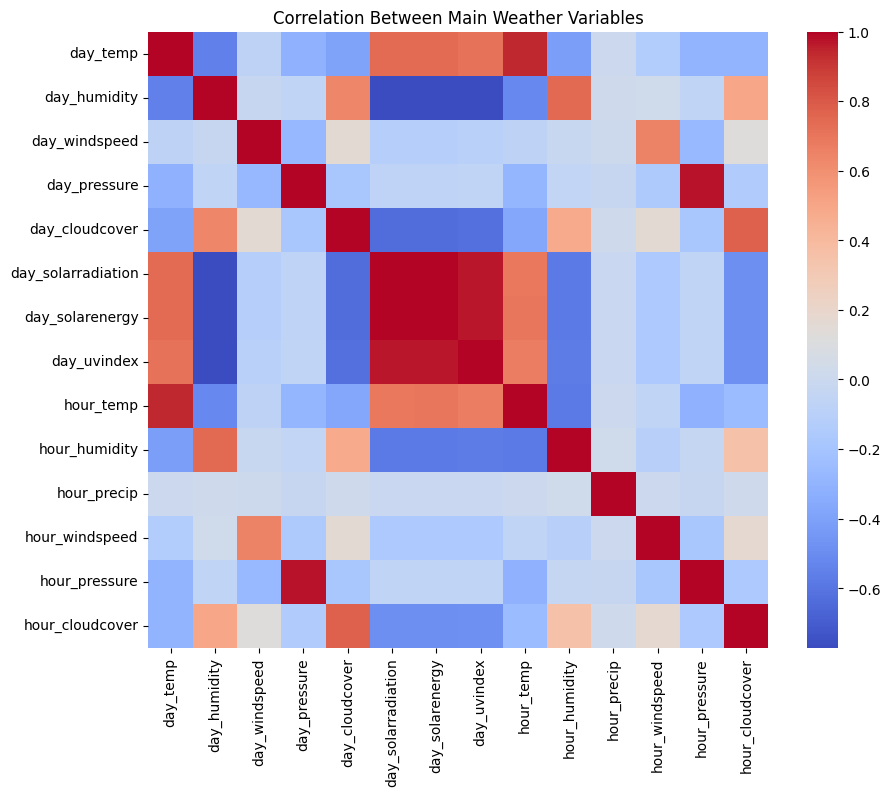

In [45]:
cols = [
    "day_temp", "day_humidity", "day_windspeed", "day_pressure",
    "day_cloudcover", "day_solarradiation", "day_solarenergy", "day_uvindex",
    "hour_temp", "hour_humidity", "hour_precip", "hour_windspeed",
    "hour_pressure", "hour_cloudcover"
]

corr = df_weather[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Main Weather Variables")
plt.show()

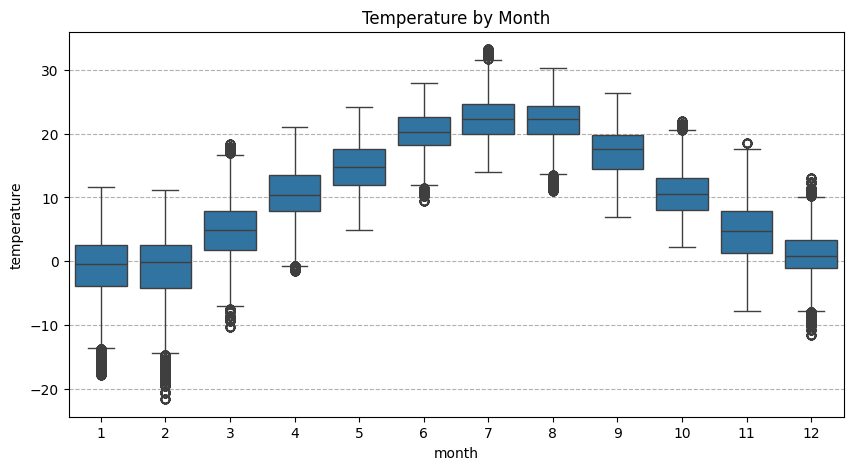

In [46]:
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_axisbelow(True)

sns.boxplot(x="month", y="day_temp", data=df_weather)
plt.title("Temperature by Month")
plt.ylabel('temperature')
plt.grid(axis="y", linestyle="--")
plt.show()

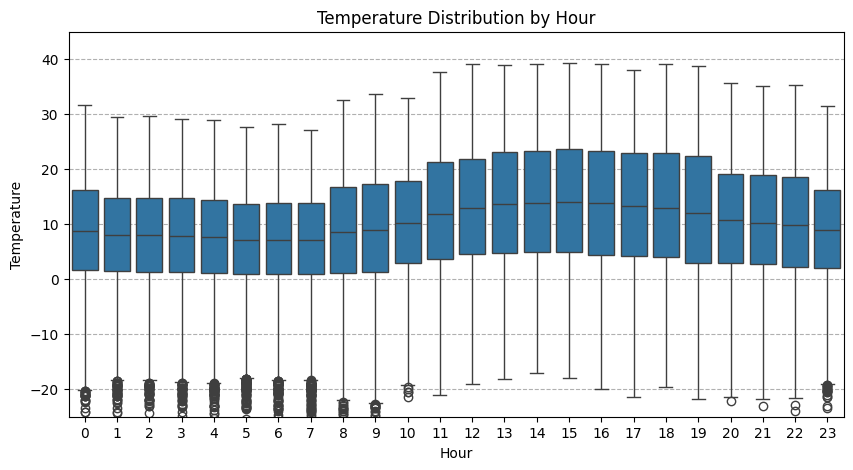

In [47]:
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_axisbelow(True)

sns.boxplot(x="hour", y="hour_temp", data=df_weather)

plt.title("Temperature Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Temperature")

plt.xticks(range(24))
plt.ylim(-25, 45)

plt.grid(axis="y", linestyle="--")

plt.show()

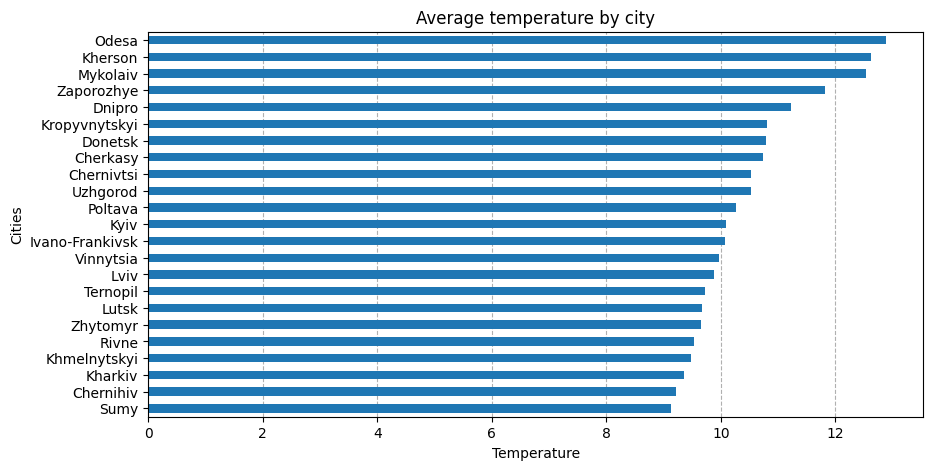

In [48]:
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_axisbelow(True)

df_weather.groupby("city_name")["hour_temp"] \
    .mean() \
    .sort_values() \
    .plot(kind="barh")

plt.grid(axis="x", linestyle="--")
plt.title("Average temperature by city")
plt.xlabel("Temperature")
plt.ylabel("Cities")
plt.show()

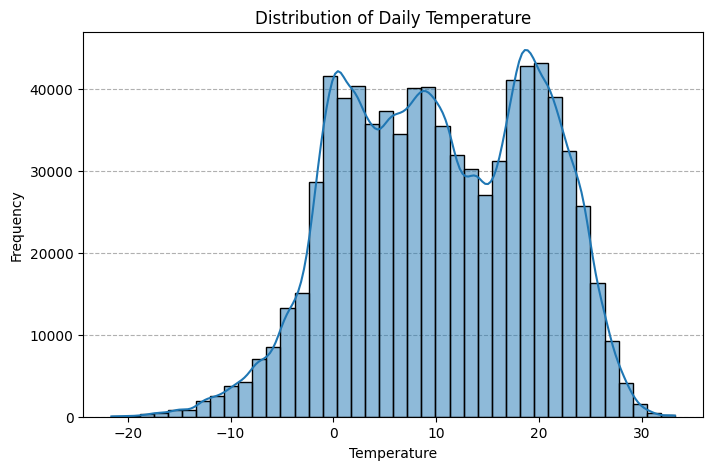

In [49]:
plt.figure(figsize=(8,5))
ax = plt.gca()
ax.set_axisbelow(True)

sns.histplot(df_weather["day_temp"], bins=40, kde=True)

plt.grid(axis="y", linestyle="--")
plt.title("Distribution of Daily Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

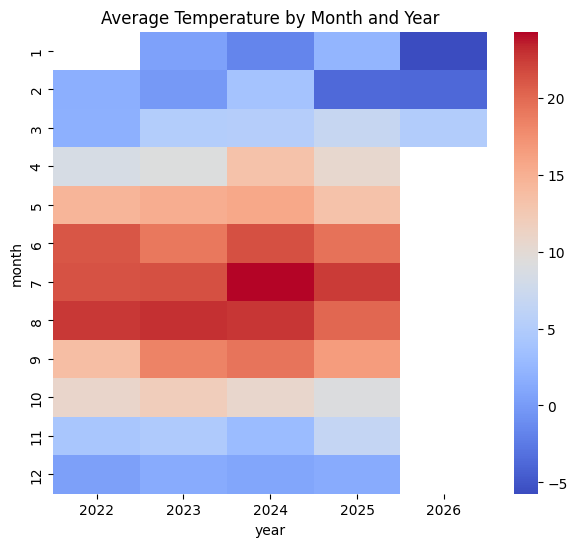

In [50]:
pivot = df_weather.pivot_table(
    values="day_temp",
    index="month",
    columns="year",
    aggfunc="mean"
)

plt.figure(figsize=(7,6))
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Average Temperature by Month and Year")
plt.show()

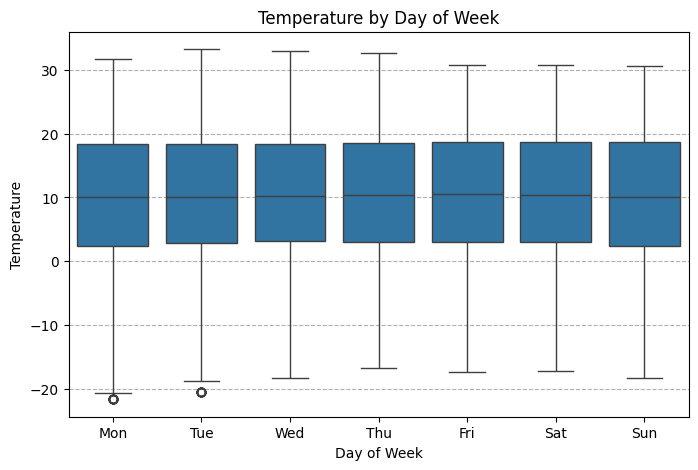

In [51]:
plt.figure(figsize=(8,5))
ax = plt.gca()
ax.set_axisbelow(True)

sns.boxplot(x="day_of_week", y="day_temp", data=df_weather)

days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
plt.xticks(range(7), days)

plt.grid(axis="y", linestyle="--")
plt.title("Temperature by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Temperature")

plt.show()

In [52]:
def plot_city(cities):
    data = df_weather[df_weather["city_name"].isin(cities)]

    city_month = (
        data.groupby(["month", "city_name"])["day_temp"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    ax.set_axisbelow(True)
    sns.lineplot(x="month", y="day_temp", hue="city_name", data=city_month)

    months = [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]

    plt.grid(axis="both", linestyle="--")
    plt.xticks(range(1, 13), months)
    plt.title("Seasonal Temperature Pattern by City")
    plt.xlabel("Month")
    plt.ylabel("Average Temperature")
    plt.show()


interact(
    plot_city,
    cities=widgets.SelectMultiple(
        options=sorted(df_weather["city_name"].unique()),
        value=(df_weather["city_name"].unique()[0],)
    )
)

interactive(children=(SelectMultiple(description='cities', index=(0,), options=('Cherkasy', 'Chernihiv', 'Cher…

<function __main__.plot_city(cities)>

## War events (alarms)

In [53]:
df_war_events_raw.shape

(76232, 9)

In [54]:
df_war_events_raw.head()

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]"
1,71822,a6fa45504565dc0928efc8807db66487,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]"
2,1746,c0ff722f9fac93e89919c7b09695dda5,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]"
3,55540,066e25a0712b306a9b95230f6ec4a051,19,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]"
4,54611,73dcb24720672b203e7c6763639860f3,18,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]"


In [55]:
df_war_events_raw.sample(5)

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms
18442,5015,bc229be37211a55b21acdb148442b8e4,4,Дніпропетровська область,Дніпропетровська обл.,1,2023-04-15 18:34:11,2023-04-15 18:57:12,"[""76070""]"
14483,11245,9575ec6979ddd687845e66872682ce65,5,Донецька область,Донецька обл.,1,2022-12-27 14:44:26,2022-12-27 16:28:41,"[""58603""]"
27566,32814,a0673f5fe2f07c34770f7faac9ca5885,10,Кіровоградська область,Кіровоградська обл.,1,2023-10-25 01:16:45,2023-10-25 03:32:03,"[""124645""]"
56074,30720,edeb16f79ccf16812f53324e0f68fcef,9,Київська область,Київська обл.,1,2025-03-05 21:11:12,2025-03-05 21:36:33,"[""158861""]"
35520,23327,e6257e8df162d0405e944e31c5115326,8,Запорізька область,Запорізька обл.,1,2024-03-21 17:56:52,2024-03-21 18:30:11,"[""136194""]"


In [56]:
df_war_events_raw.describe()

,id,region_id,all_region
count,76232.000000,76232.000000,76232.000000
mean,38138.351611,12.477359,0.972820
std,22026.175622,6.446595,0.162609
min,1.000000,1.000000,0.000000
25%,19063.750000,7.000000,1.000000
50%,38129.500000,13.000000,1.000000
75%,57210.250000,19.000000,1.000000
max,76880.000000,24.000000,1.000000


In [57]:
df_war_events_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76232 entries, 0 to 76231
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               76232 non-null  int64 
 1   merged_id        76232 non-null  object
 2   region_id        76232 non-null  int64 
 3   region_title     76232 non-null  object
 4   region_city      76232 non-null  object
 5   all_region       76232 non-null  int64 
 6   start            76232 non-null  object
 7   end              76232 non-null  object
 8   original_alarms  76232 non-null  object
dtypes: int64(3), object(6)
memory usage: 5.2+ MB


In [58]:
print("Missing values:\n", df_war_events_raw.isna().sum())
print("\nDuplicate rows:", df_war_events_raw.duplicated().sum())
print("Duplicate id:", df_war_events_raw.duplicated(subset=["id"]).sum())

Missing values:
 id                 0
merged_id          0
region_id          0
region_title       0
region_city        0
all_region         0
start              0
end                0
original_alarms    0
dtype: int64

Duplicate rows: 0
Duplicate id: 0


In [59]:
df_war_events_raw[df_war_events_raw["all_region"] == 0]["region_city"].value_counts()

region_city
Київ    2072
Name: count, dtype: int64

In [60]:
df_war_events = df_war_events_raw.copy()

In [61]:
df_war_events["start"] = pd.to_datetime(df_war_events["start"], errors="coerce")
df_war_events["end"] = pd.to_datetime(df_war_events["end"], errors="coerce")

print("Invalid start dates:", df_war_events["start"].isna().sum())
print("Invalid end dates:", df_war_events["end"].isna().sum())

print(df_war_events[["start", "end"]].dtypes)

Invalid start dates: 0
Invalid end dates: 0
start    datetime64[ns]
end      datetime64[ns]
dtype: object


In [62]:
print("Min start:", df_war_events["start"].min())
print("Max start:", df_war_events["start"].max())

print("Min end:", df_war_events["end"].min())
print("Max end:", df_war_events["end"].max())

Min start: 2022-02-24 07:43:17
Max start: 2026-03-16 23:32:09
Min end: 2022-02-24 09:52:28
Max end: 2026-03-17 07:26:30


In [63]:
df_war_events["duration_min"] = (df_war_events["end"] - df_war_events["start"]).dt.total_seconds() / 60

print(df_war_events["duration_min"].describe())

count    76232.000000
mean        90.888377
std        142.248317
min       -781.700000
25%         26.666667
50%         42.783333
75%        100.500000
max       5265.200000
Name: duration_min, dtype: float64


In [64]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())
print("Zero durations:", (df_war_events["duration_min"] == 0).sum())

Negative durations: 2
Zero durations: 0


In [65]:
df_war_events[df_war_events["duration_min"] < 0]

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms,duration_min
47988,52102,4abbedd62b6f1a99d4153bcb3f691b96,17,Сумська область,Сумська обл.,1,2024-10-01 20:53:04,2024-10-01 07:51:22,"[""150000""]",-781.700000
68290,42965,a5b4bad0603b085be8a6114690ebde0d,14,Одеська область,Одеська обл.,1,2025-10-26 03:55:59,2025-10-26 03:13:37,"[""230277""]",-42.366667


In [66]:
print("Shape before removing negative durations:", df_war_events.shape)
df_war_events[df_war_events["duration_min"] >= 0].copy()
print("Shape after removing negative durations:", df_war_events.shape)

Shape before removing negative durations: (76232, 10)
Shape after removing negative durations: (76232, 10)


In [67]:
df_war_events["region_key"] = (df_war_events["region_city"].str.replace(" обл.", ""))

In [68]:
alarm_regions = sorted(df_war_events[df_war_events["all_region"] == 1]["region_key"].unique())

regions = df_regions["region"]

missing_in_alarms = sorted(set(regions) - set(alarm_regions))
extra_in_alarms = sorted(set(alarm_regions) - set(regions))

print("Missing regions in alarms:", missing_in_alarms)
print("Extra regions in alarms:", extra_in_alarms)

Missing regions in alarms: ['АР Крим', 'Луганська']
Extra regions in alarms: []


**Luhansk and Crimea regions are missing** in the alarms dataset.

In [69]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))
id_mismatch

Number of ID mismatches: 18


,region_id_alarms,region_key,region_id_regions
0,12,Львівська,13
1,23,Чернігівська,25
2,3,Вінницька,2
3,19,Харківська,20
4,18,Тернопільська,19
5,16,Рівненська,17
6,22,Черкаська,23
7,14,Одеська,15
9,2,Волинська,3
11,20,Херсонська,21


In [70]:
region_id_map = df_regions.set_index("region")["region_id"].to_dict()

df_war_events["region_id"] = df_war_events["region_key"].map(region_id_map)
df_war_events.loc[df_war_events["region_key"] == "Київ", "region_id"] = 26

print("Missing region_id after remapping:", df_war_events["region_id"].isna().sum())
print(df_war_events[["region_city", "region_key", "region_id"]].sample(10))

Missing region_id after remapping: 0
                  region_city         region_key  region_id
35795            Одеська обл.            Одеська       15.0
28359         Запорізька обл.         Запорізька        8.0
75980          Черкаська обл.          Черкаська       23.0
12700         Запорізька обл.         Запорізька        8.0
52813        Чернівецька обл.        Чернівецька       24.0
28111       Чернігівська обл.       Чернігівська       25.0
31739   Дніпропетровська обл.   Дніпропетровська        4.0
6917             Одеська обл.            Одеська       15.0
5217   Івано-Франківська обл.  Івано-Франківська        9.0
15954            Сумська обл.            Сумська       18.0


In [71]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))

Number of ID mismatches: 0


In [72]:
df_war_events.head()

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms,duration_min,region_key
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,13.0,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]",129.183333,Львівська
1,71822,a6fa45504565dc0928efc8807db66487,25.0,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]",191.000000,Чернігівська
2,1746,c0ff722f9fac93e89919c7b09695dda5,2.0,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]",30.000000,Вінницька
3,55540,066e25a0712b306a9b95230f6ec4a051,20.0,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]",48.000000,Харківська
4,54611,73dcb24720672b203e7c6763639860f3,19.0,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]",420.716667,Тернопільська


In [73]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_DARK = "#1D4E89"
BLUE_MAIN = "#2F6DB3"
BLUE_SOFT = "#A9C6E8"
BLUE_LIGHT = "#DCEAF7"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)

def add_subtitle(fig, text):
    fig.text(0.125, 0.92, text, fontsize=10, color=TEXT_GREY)

In [74]:
df_plot = df_war_events.copy()

df_plot["year_month"] = df_plot["start"].dt.to_period("M")
df_plot["hour"] = df_plot["start"].dt.hour
df_plot["weekday"] = df_plot["start"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

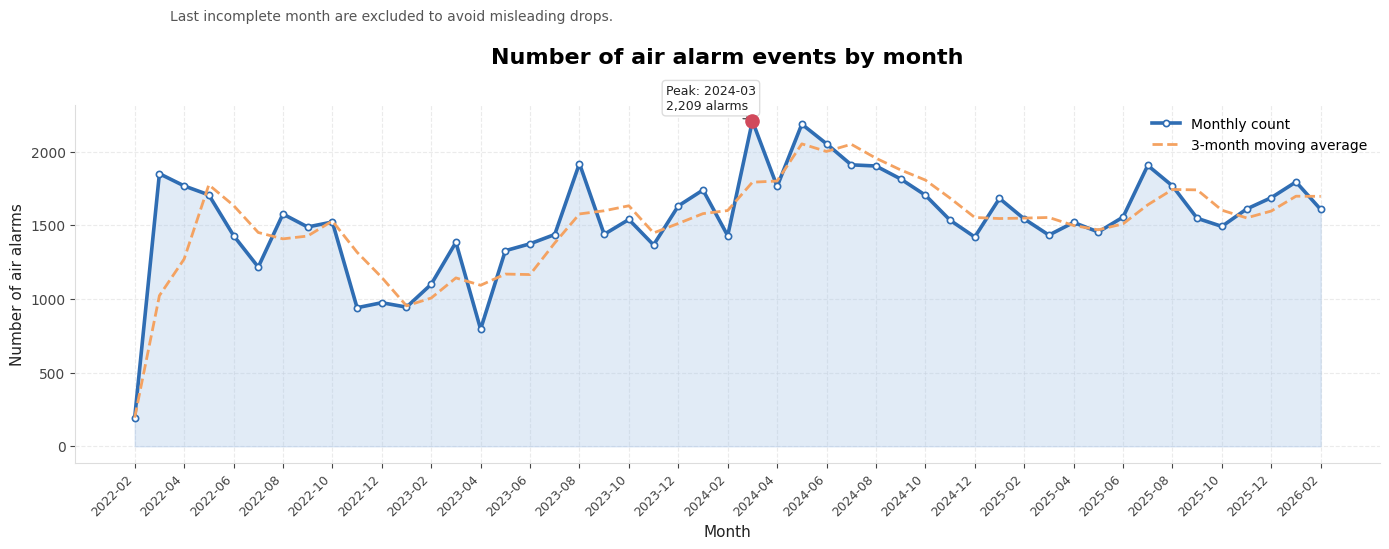

In [75]:
monthly_counts = df_plot.groupby("year_month").size().sort_index()
monthly_counts_plot = monthly_counts.iloc[:-1]

x_labels = monthly_counts_plot.index.astype(str).tolist()
y_values = monthly_counts_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_counts_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Monthly count"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)

ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} alarms",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(x[peak_idx] - 3.5, y_values[peak_idx] + 80),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY),
    fontsize=9,
    color="#222222",
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_title("Number of air alarm events by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Number of air alarms")

ax.legend(frameon=False)

style_ax(ax, "both")
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

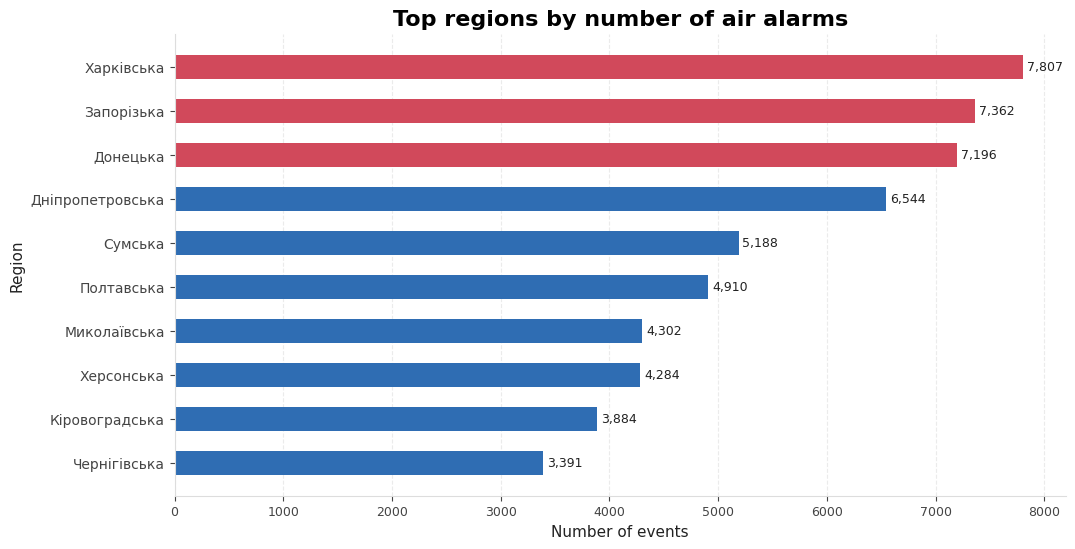

In [76]:
region_counts = df_plot.groupby("region_key").size().sort_values(ascending=False).head(10)

plot_region_counts = region_counts.sort_values()
top3_regions = set(region_counts.head(3).index)

bar_colors = [
    RED_ACCENT if region in top3_regions 
    else BLUE_MAIN for region in plot_region_counts.index
]

fig, ax = plt.subplots(figsize=(11.5, 6))

bars = ax.barh(
    plot_region_counts.index,
    plot_region_counts.values,
    color=bar_colors,
    height=0.55
)

for bar, value in zip(bars, plot_region_counts.values):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9,
        color="#222222"
    )

ax.set_title("Top regions by number of air alarms")
ax.set_xlabel("Number of events")
ax.set_ylabel("Region")
style_ax(ax, "x")
plt.show()

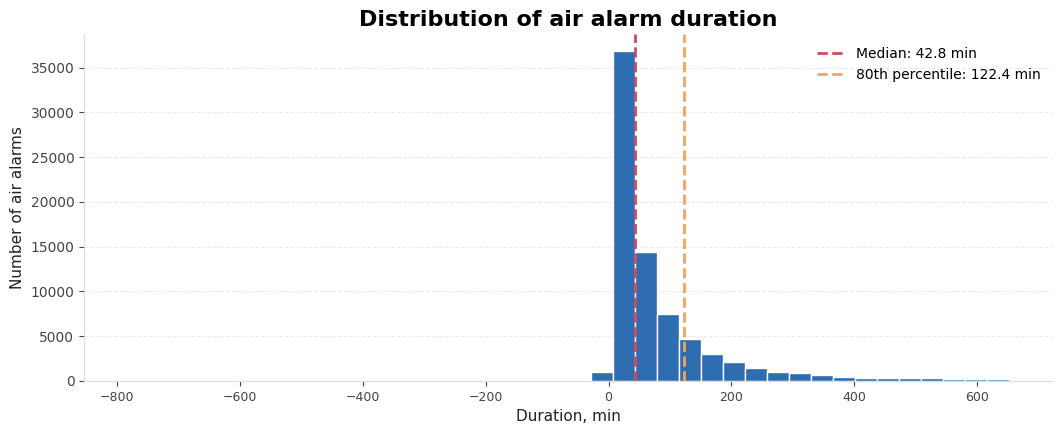

In [77]:
duration_min = df_plot["duration_min"].copy()
p99 = duration_min.quantile(0.99)
p80 = duration_min.quantile(0.80)
median_val = duration_min.median()

dur_clipped = duration_min[duration_min <= p99]

fig, ax = plt.subplots(figsize=(12.5, 4.5))

ax.hist(
    dur_clipped,
    bins=40,
    color=BLUE_MAIN,
    edgecolor="white"
)

ax.axvline(median_val, color=RED_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_val:.1f} min")
ax.axvline(p80, color=GOLD, linestyle="--", linewidth=2, label=f"80th percentile: {p80:.1f} min")

ax.set_title("Distribution of air alarm duration")
ax.set_xlabel("Duration, min")
ax.set_ylabel("Number of air alarms")
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")
plt.show()

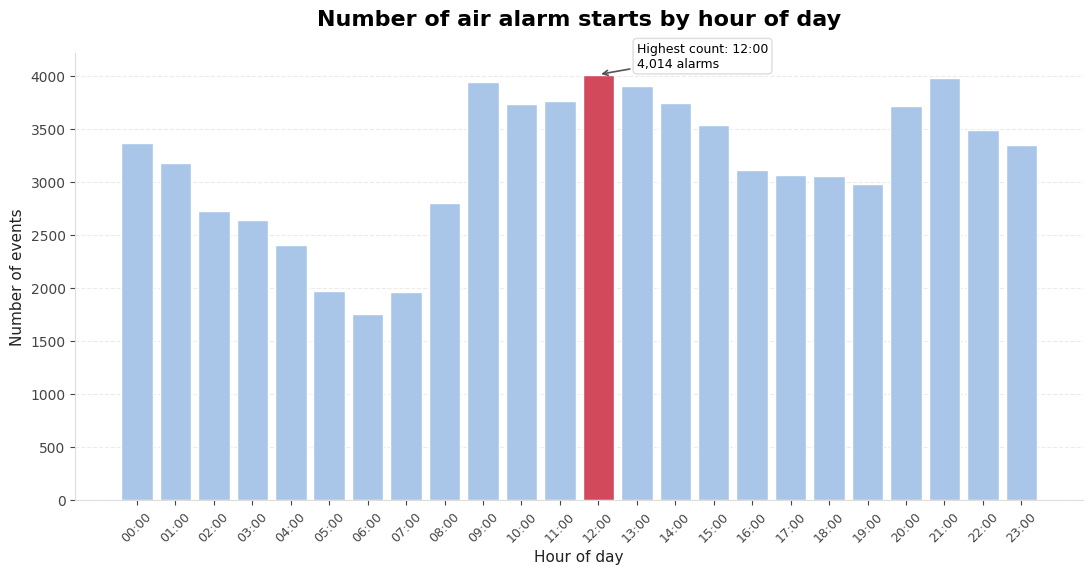

In [78]:
hour_counts = df_plot.groupby("hour").size()

top_hour = hour_counts.idxmax()
hour_colors = [BLUE_SOFT] * 24
hour_colors[top_hour] = RED_ACCENT

fig, ax = plt.subplots(figsize=(13, 5.8))
bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="white",
    width=0.82
)

ax.annotate(
    f"Highest count: {top_hour:02d}:00\n{hour_counts[top_hour]:,} alarms",
    xy=(top_hour, hour_counts[top_hour]),
    xytext=(top_hour + 1, hour_counts[top_hour] + 70),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY, lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title("Number of air alarm starts by hour of day", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of events")
style_ax(ax, "y")
plt.show()

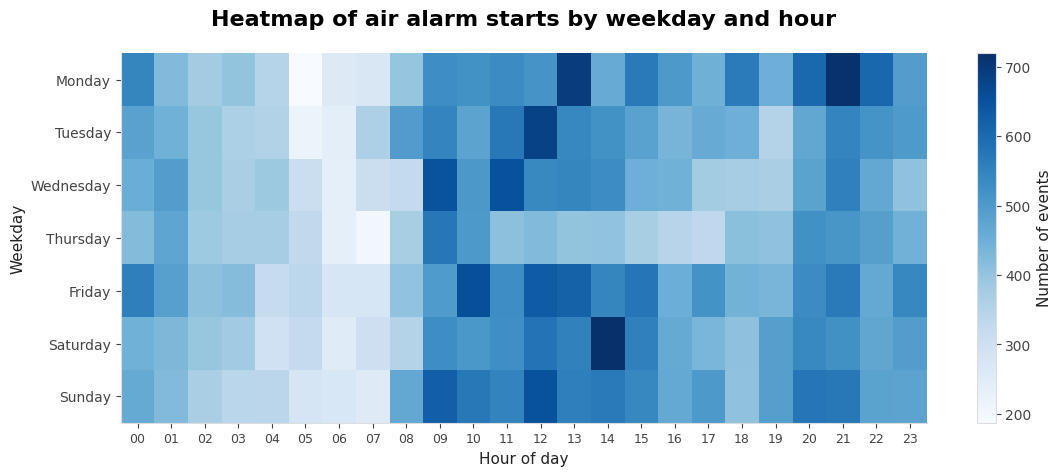

In [79]:
heatmap_data = (
    df_plot.groupby(["weekday", "hour"]).size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Heatmap of air alarm starts by weekday and hour", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of events")
plt.show()

## ISW

In [80]:
df_isw_raw.shape

(1483, 4)

In [81]:
df_isw_raw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Previous\nNext\nUkraine Conflict Update 7\nRus...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...


In [82]:
df_isw_raw.sample(5)

,date,title,url,text
923,2024-09-03,"Russian Offensive Campaign Assessment, Septemb...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
298,2022-12-18,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
93,2022-05-27,"Russian Offensive Campaign Assessment, May 27,...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
1436,2026-01-29,"Russian Offensive Campaign Assessment, January...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
1035,2024-12-24,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [83]:
df_isw_raw.describe()

,date,title,url,text
count,1483,1483,1483,1483
unique,1482,1471,1471,1471
top,2022-02-24,None,None,None
freq,2,13,13,13


In [84]:
df_isw_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1483 entries, 0 to 1482
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1483 non-null   object
 1   title   1483 non-null   object
 2   url     1483 non-null   object
 3   text    1483 non-null   object
dtypes: object(4)
memory usage: 46.5+ KB


All columns currently have the `object` data type. 

In [85]:
df_isw = df_isw_raw.copy()

In [86]:
for col in ["date","title", "url", "text"]:
    df_isw[col] = df_isw[col].replace("None", np.nan)

In [87]:
df_isw["date"] = pd.to_datetime(df_isw["date"], errors="coerce")
print("Invalid dates:", df_isw["date"].isna().sum())
print(df_isw["date"].dtype)

Invalid dates: 0
datetime64[ns]


In [88]:
outside_range = df_isw[(df_isw["date"] < "2022-02-24") | (df_isw["date"] > "2026-03-16")]
print(outside_range)

Empty DataFrame
Columns: [date, title, url, text]
Index: []


In [89]:
print("Missing values:", df_isw.isna().sum())

Missing values: date      0
title    13
url      13
text     13
dtype: int64


In [90]:
print("Duplicate dates:", df_isw["date"].duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].dropna().duplicated().sum())
print("Duplicate non-missing urls:", df_isw["url"].dropna().duplicated().sum())
print("Duplicate non-missing text:", df_isw["text"].dropna().duplicated().sum())
print("Duplicate full rows:", df_isw.duplicated().sum())

Duplicate dates: 1
Duplicate non-missing titles: 0
Duplicate non-missing urls: 0
Duplicate non-missing text: 0
Duplicate full rows: 0


In [91]:
dup_dates = df_isw[df_isw["date"].duplicated(keep=False)]
dup_dates[["date", "title", "url"]]

,date,title,url
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...


In [92]:
df_isw = df_isw.dropna(subset=["title", "url", "text"]).copy()

In [93]:
print("Missing values:", df_isw.isna().sum())

Missing values: date     0
title    0
url      0
text     0
dtype: int64


In [94]:
def clean_isw_text(text):
    text = str(text)
    text = text.replace("Previous\nNext", " ")
    text = text.replace("Click\nhere", " ")
    text = text.replace("\n", " ")
    return text

df_isw["text_clean"] = df_isw["text"].apply(clean_isw_text)

In [95]:
df_isw["text"] = df_isw["text_clean"]
df_isw = df_isw.drop(columns=["text_clean"])

In [96]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Ukraine Conflict Update 7 Russia Team Februa...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...


In [97]:
df_isw_plot = df_isw.copy()

df_isw_plot["year"] = df_isw_plot["date"].dt.year
df_isw_plot["year_month"] = df_isw_plot["date"].dt.to_period("M")
df_isw_plot["word_count"] = df_isw_plot["text"].str.split().str.len()
df_isw_plot["char_count"] = df_isw_plot["text"].str.len()

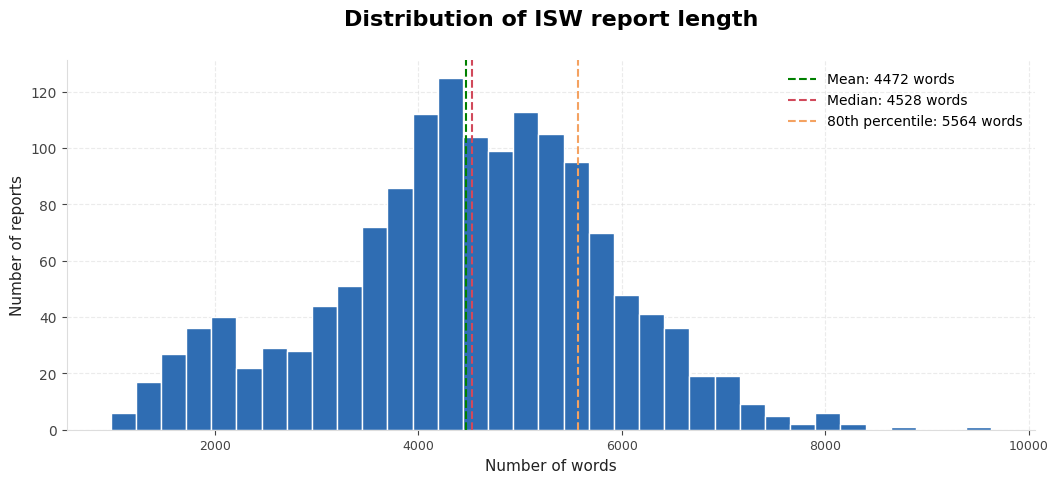

In [98]:
word_count = df_isw_plot["word_count"].copy()

p80 = word_count.quantile(0.80)
median_val = word_count.median()
mean_val = word_count.mean()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(word_count, bins=35, color=BLUE_MAIN,edgecolor="white")

ax.axvline(
    mean_val,
    color="green",
    linestyle="--",
    label=f"Mean: {mean_val:.0f} words"
)
ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} words"
)
ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} words"
)

ax.set_title("Distribution of ISW report length", pad=25)
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of reports")
style_ax(ax, "both")
ax.legend(frameon=False, loc="upper right")
plt.show()

Distribution is not perfectly symmetric and appears to have tails on both sides, with most reports concentrated between roughly 4000 and 5500 words. 80% of reports are shorter than 5565 words.

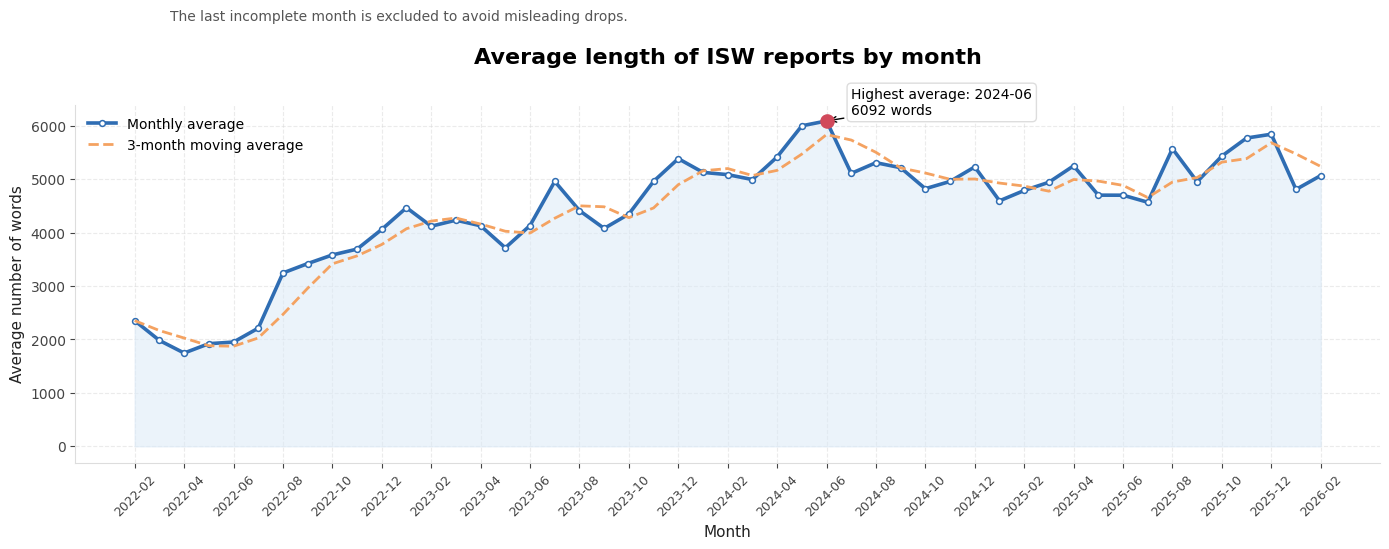

In [99]:
monthly_avg_words = df_isw_plot.groupby("year_month")["word_count"].mean().sort_index()
monthly_avg_words_plot = monthly_avg_words.iloc[:-1]

x_labels = monthly_avg_words_plot.index.astype(str).tolist()
y_values = monthly_avg_words_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_avg_words_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_LIGHT, alpha=0.55)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.2,
    markerfacecolor="white",
    markeredgewidth=1.1,
    label="Monthly average"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Highest average: {x_labels[peak_idx]}\n{y_values[peak_idx]:.0f} words",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] + 1), y_values[peak_idx] + 120),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Average length of ISW reports by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Average number of words")

ax.legend(frameon=False)
style_ax(ax, "both")
add_subtitle(fig, "The last incomplete month is excluded to avoid misleading drops.")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Line chart shows that the average report length was lower in 2022 and became higher and more stable in later periods.

## Telegram 

In [100]:
df_tg_raw.shape

(130418, 3)

In [101]:
df_tg_raw.head()

,date,channel,message
0,2026-03-16 23:31:21+00:00,kpszsu,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...
1,2026-03-16 23:21:32+00:00,kpszsu,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...
2,2026-03-16 22:45:16+00:00,kpszsu,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...
3,2026-03-16 22:33:10+00:00,kpszsu,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...
4,2026-03-16 21:30:39+00:00,kpszsu,🛵 БпЛА у напрямку Павлограду зі сходу.


In [102]:
df_tg_raw.sample(5)

,date,channel,message
59654,2022-10-17 10:04:40+00:00,UkraineNow,⚡️**Укроборонпром анонсував українську відпові...
119854,2024-02-28 11:22:34+00:00,kpszsu,⚠ Увага!\n🚀 Харківська область – ракетна небез...
41173,2024-01-12 09:03:12+00:00,UkraineNow,"**Ні Україна, ні росія не можуть проводити нас..."
34193,2024-06-11 11:50:32+00:00,UkraineNow,**Активність ворожої тактичної авіації на сход...
118951,2024-03-22 02:59:39+00:00,kpszsu,🚀Крилата ракета на Запоріжжі у напрямку Кірово...


In [103]:
df_tg_raw.describe()

,date,channel,message
count,130418,130418,130418
unique,130226,3,107963
top,2025-10-23 03:28:04+00:00,UkraineNow,📢 Відбій загрози.
freq,6,61363,929


In [104]:
df_tg_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130418 entries, 0 to 130417
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     130418 non-null  object
 1   channel  130418 non-null  object
 2   message  130418 non-null  object
dtypes: object(3)
memory usage: 3.0+ MB


In [105]:
print("Unique channels:", df_tg_raw["channel"].nunique())
print(df_tg_raw["channel"].value_counts())

Unique channels: 3
channel
UkraineNow     61363
kpszsu         57216
DeepStateUA    11839
Name: count, dtype: int64


In [106]:
print("Duplicate rows:",
      df_tg_raw.duplicated(subset=["date", "channel", "message"]).sum())

print("Duplicate messages:",
      df_tg_raw.duplicated(subset=["message"]).sum())

Duplicate rows: 47
Duplicate messages: 22455


In [107]:
df_tg = df_tg_raw.copy()

In [108]:
df_tg["date"] = pd.to_datetime(df_tg["date"], utc=True, errors="coerce")
df_tg["date"] = df_tg["date"].dt.tz_convert("Europe/Kyiv")
df_tg["date"] = df_tg["date"].dt.tz_localize(None)

print("Invalid dates:", df_tg["date"].isna().sum())
print(df_tg["date"].dtype)

Invalid dates: 0
datetime64[ns]


In [109]:
print("Min date:", df_tg["date"].min())
print("Max date:", df_tg["date"].max())

Min date: 2022-02-24 05:51:12
Max date: 2026-03-17 01:31:21


In [110]:
df_tg["message"] = df_tg["message"].astype(str)

print("Empty messages:", (df_tg["message"] == "").sum())
print("Whitespace messages:", df_tg["message"].str.strip().eq("").sum())

print("\nShortest messages:")
print(df_tg.loc[df_tg["message"].str.len().nsmallest(10).index, ["channel", "date", "message"]])

Empty messages: 0
Whitespace messages: 0

Shortest messages:
           channel                date message
2159   DeepStateUA 2025-06-01 14:49:49       🕸
4993   DeepStateUA 2024-02-16 14:20:06       🥪
8413   DeepStateUA 2022-11-11 13:10:16       🍉
10472  DeepStateUA 2022-04-12 21:46:52       😎
10745  DeepStateUA 2022-04-01 07:39:05       😳
10985  DeepStateUA 2022-03-22 18:42:05       💸
11104  DeepStateUA 2022-03-17 23:02:54       😐
11611  DeepStateUA 2022-03-04 18:47:06       🤨
11624  DeepStateUA 2022-03-04 14:53:13       🍾
11739  DeepStateUA 2022-03-03 09:02:20       🔴


In [111]:
CHANNEL_COLORS = {
    "UkraineNow": "green" ,
    "kpszsu": GOLD,
    "DeepStateUA": BLUE_DARK
}

In [112]:
df_tg["time"] = df_tg["date"].dt.strftime("%H:%M:%S")
df_tg["hour"] = df_tg["date"].dt.hour
df_tg["year_month"] = df_tg["date"].dt.to_period("M")
df_tg["date_day"] = df_tg["date"].dt.floor("D")

In [113]:
df_tg

,date,channel,message,time,hour,year_month,date_day
0,2026-03-17 01:31:21,kpszsu,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...,01:31:21,1,2026-03,2026-03-17
1,2026-03-17 01:21:32,kpszsu,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...,01:21:32,1,2026-03,2026-03-17
2,2026-03-17 00:45:16,kpszsu,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...,00:45:16,0,2026-03,2026-03-17
3,2026-03-17 00:33:10,kpszsu,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...,00:33:10,0,2026-03,2026-03-17
4,2026-03-16 23:30:39,kpszsu,🛵 БпЛА у напрямку Павлограду зі сходу.,23:30:39,23,2026-03,2026-03-16
...,...,...,...,...,...,...,...
130413,2022-02-25 09:45:10,kpszsu,Вибухи на аеродромі Міллєрово в Ростовській об...,09:45:10,9,2022-02,2022-02-25
130414,2022-02-25 09:43:53,kpszsu,🛩🛩🛩🛩\nДо строю авіації Повітряних Сил Збройних...,09:43:53,9,2022-02,2022-02-25
130415,2022-02-25 00:43:47,kpszsu,ПОВІТРЯНІ СИЛИ ЗАВДАЛИ ВОРОГУ СУТТЄВИХ ВТРАТ\n...,00:43:47,0,2022-02,2022-02-25
130416,2022-02-25 00:43:23,kpszsu,https://fb.watch/bnMUkUvwfp/,00:43:23,0,2022-02,2022-02-25


In [114]:
df_tg_plot = df_tg.copy()

In [115]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
df_tg_plot["weekday"] = pd.Categorical(
    df_tg_plot["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

df_tg_plot["message_len"] = df_tg_plot["message"].str.len()
df_tg_plot["word_count"] = df_tg_plot["message"].str.split().str.len()
df_tg_plot["is_duplicate_within_channel"] = df_tg_plot.duplicated(subset=["channel", "message"])
df_tg_plot.head()

,date,channel,message,time,hour,year_month,date_day,weekday,message_len,word_count,is_duplicate_within_channel
0,2026-03-17 01:31:21,kpszsu,🛵 Групи ворожих БпЛА у напрямку Кілії та Катла...,01:31:21,1,2026-03,2026-03-17,Tuesday,51,9,False
1,2026-03-17 01:21:32,kpszsu,🛵 Групи ворожих БпЛА у Чорному морі курсом на ...,01:21:32,1,2026-03,2026-03-17,Tuesday,58,10,False
2,2026-03-17 00:45:16,kpszsu,🛵 Ворожі БпЛА у напрямку Сергіївки з Чорного м...,00:45:16,0,2026-03,2026-03-17,Tuesday,50,9,False
3,2026-03-17 00:33:10,kpszsu,🛵 Ворожі БпЛА через Сумщину зі сходу у західно...,00:33:10,0,2026-03,2026-03-17,Tuesday,58,10,False
4,2026-03-16 23:30:39,kpszsu,🛵 БпЛА у напрямку Павлограду зі сходу.,23:30:39,23,2026-03,2026-03-16,Monday,38,7,False


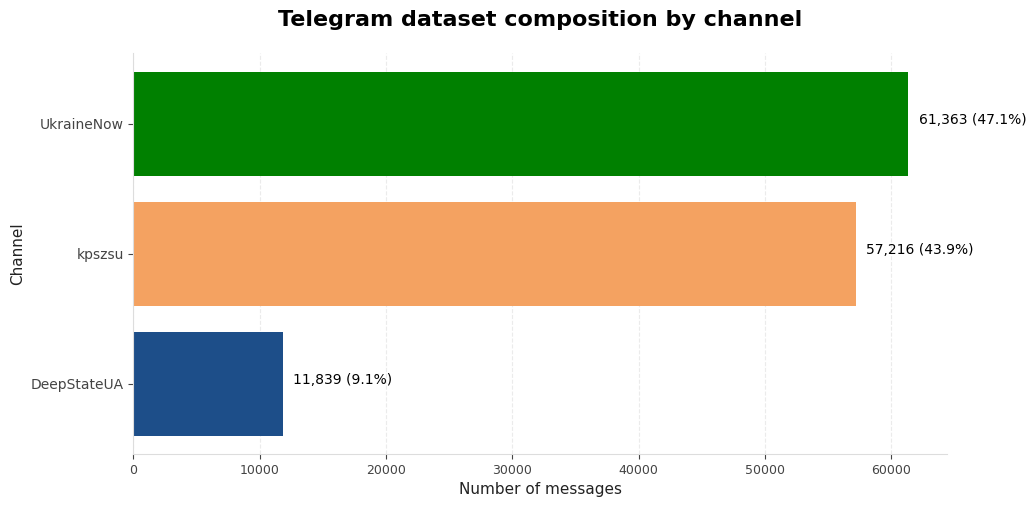

In [116]:
channel_counts = df_tg_plot["channel"].value_counts().sort_values()
channel_counts_percent = channel_counts / channel_counts.sum() * 100 

bar_colors = [CHANNEL_COLORS[channel] for channel in channel_counts.index]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.barh(
    channel_counts.index,
    channel_counts.values,
    color=bar_colors,
)

for bar, count, share in zip(bars, channel_counts.values, channel_counts_percent.values):
    ax.text(
        count + 800,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({share:.1f}%)",
        fontsize=10
    )

ax.set_title("Telegram dataset composition by channel", pad=20)
ax.set_xlabel("Number of messages")
ax.set_ylabel("Channel")
style_ax(ax, "x")
plt.show()

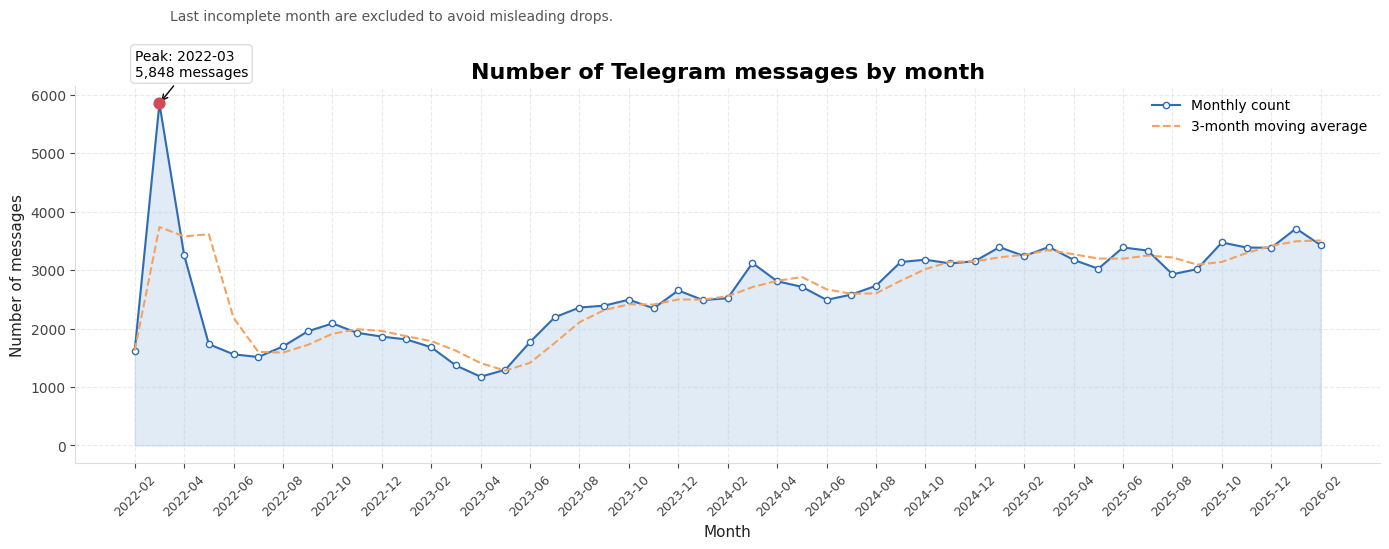

In [117]:
monthly_total = (df_tg_plot.groupby("year_month").size())

last_day = df_tg_plot["date"].max()
last_month_complete = last_day.day == last_day.days_in_month
if last_month_complete:
    monthly_total_plot = monthly_total.copy()
else:
    monthly_total_plot = monthly_total.iloc[:-1]

x_labels = monthly_total_plot.index.astype(str).tolist()
y_values = monthly_total_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_total_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    label="Monthly count"
)
ax.plot(
    x, moving_avg,
    color=GOLD,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=60, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} messages",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] - 4), y_values[peak_idx] + y_values.max() * 0.08),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Number of Telegram messages by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False)
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")
style_ax(ax, "both")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

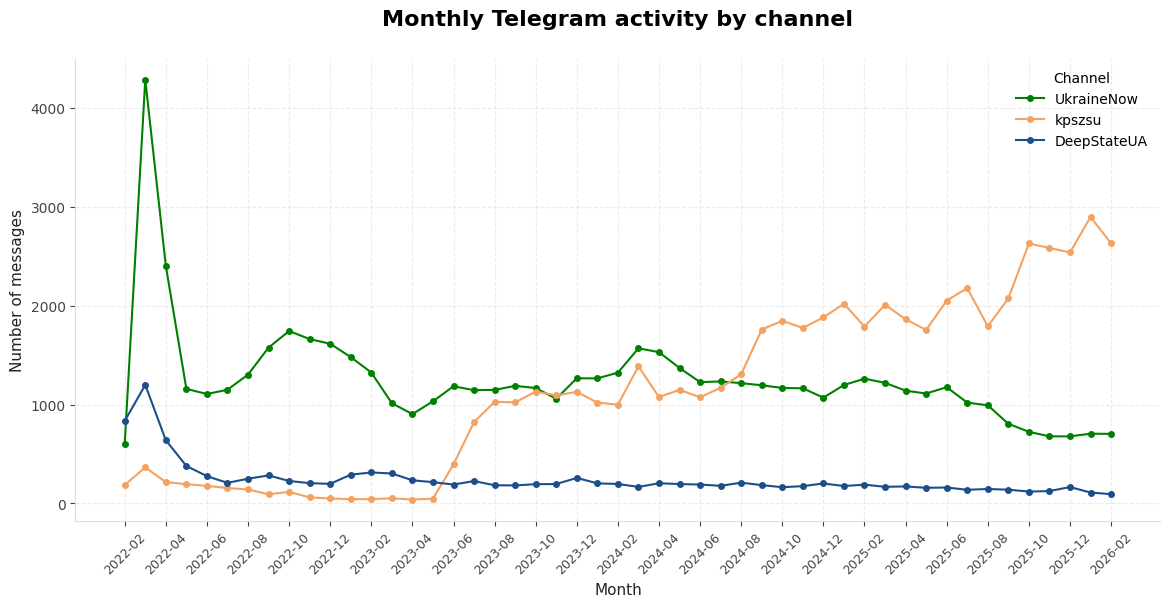

In [118]:
monthly_by_channel = (
    df_tg_plot.groupby(["year_month", "channel"])
    .size()
    .reset_index(name="messages_count")
)

if not last_month_complete:
    monthly_by_channel = monthly_by_channel[
        monthly_by_channel["year_month"] != monthly_by_channel["year_month"].max()
    ].copy()

monthly_by_channel["year_month_str"] = monthly_by_channel["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for channel in ["UkraineNow", "kpszsu", "DeepStateUA"]:
    temp = monthly_by_channel[monthly_by_channel["channel"] == channel]
    ax.plot(
        temp["year_month_str"],
        temp["messages_count"],
        label=channel,
        color=CHANNEL_COLORS[channel],
        marker="o",
        markersize=4
    )

tick_idx = np.arange(0, monthly_by_channel["year_month_str"].nunique(), 2)
unique_months = monthly_by_channel["year_month_str"].drop_duplicates().tolist()

ax.set_xticks(tick_idx)
ax.set_xticklabels([unique_months[i] for i in tick_idx], rotation=45)
ax.set_title("Monthly Telegram activity by channel", pad=24)
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(title="Channel", frameon=False)
style_ax(ax, "both")
plt.show()

C:\Users\vikam\AppData\Local\Temp\ipykernel_21196\790425606.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tg_plot.groupby(["weekday", "hour"])


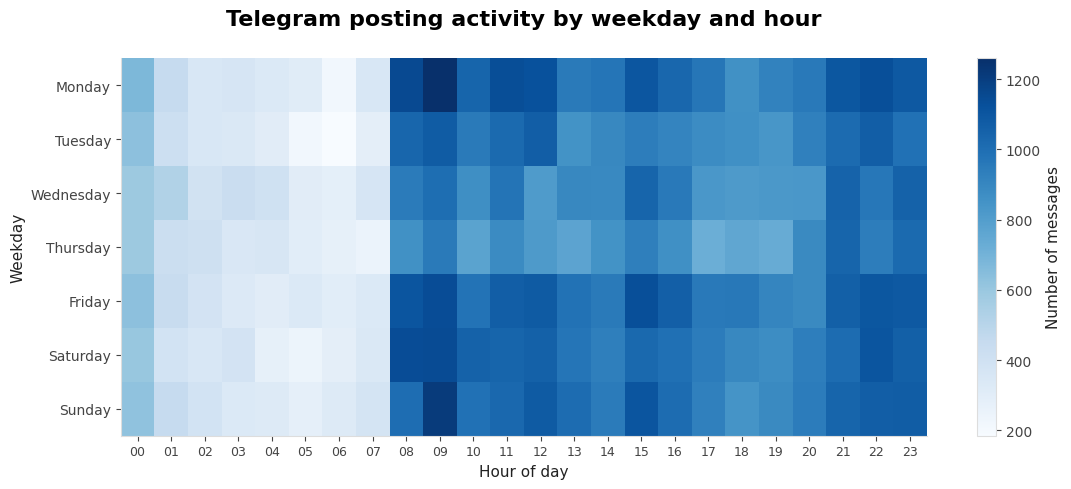

In [119]:
heatmap_data = (
    df_tg_plot.groupby(["weekday", "hour"])
    .size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.9))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Telegram posting activity by weekday and hour", pad=24)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of messages")
plt.show()

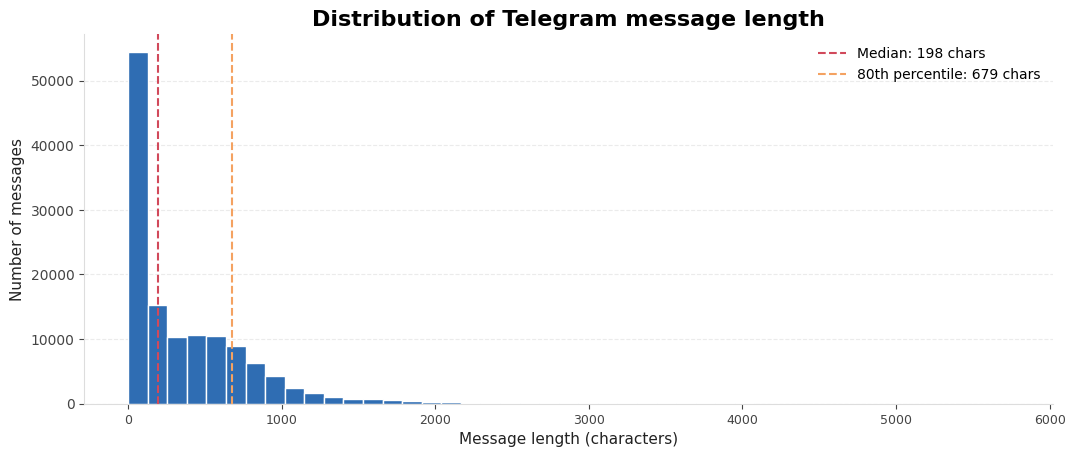

In [120]:
message_len = df_tg_plot["message_len"].copy()

p80 = message_len.quantile(0.80)
median_val = message_len.median()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(
    message_len,
    bins=45,
    color=BLUE_MAIN,
    edgecolor="white",
)

ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} chars"
)

ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} chars"
)

ax.set_title("Distribution of Telegram message length")
ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False, loc="upper right")
style_ax(ax, "y")
plt.show()

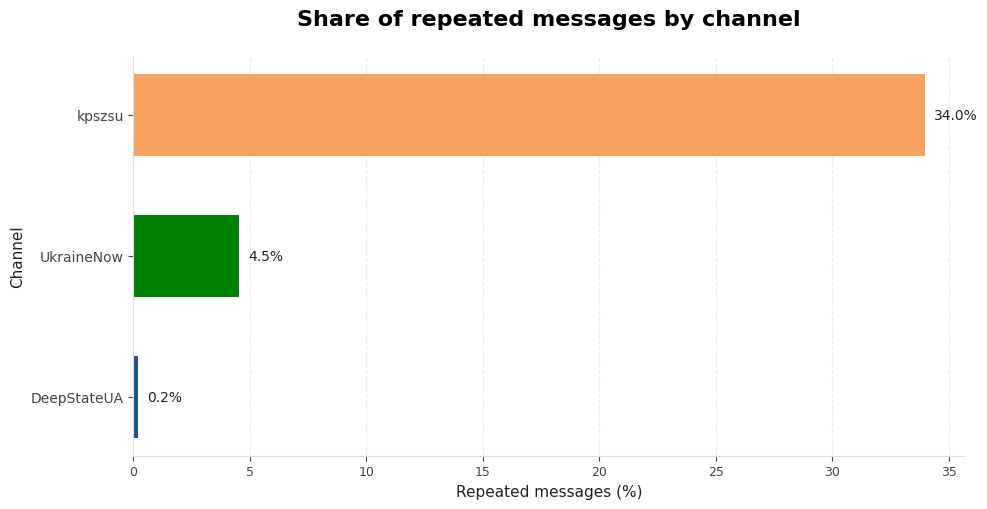

In [121]:
dup_share = (
    df_tg_plot.groupby("channel")["is_duplicate_within_channel"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5.2))

bars = ax.barh(
    dup_share.index,
    dup_share.values,
    color=[CHANNEL_COLORS[ch] for ch in dup_share.index],
    height=0.58
)

for bar, value in zip(bars, dup_share.values):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        color="#222222"
    )

ax.set_title("Share of repeated messages by channel", pad=22)
ax.set_xlabel("Repeated messages (%)")
ax.set_ylabel("Channel")

style_ax(ax, "x")
plt.tight_layout()
plt.show()

# IV. Prepare data(NLP, PCA, EDA for tf-idf vectors)

## ISW

In [122]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-24,Ukraine Conflict Update 7,https://understandingwar.org/research/russia-u...,Ukraine Conflict Update 7 Russia Team Februa...
2,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...


In [123]:
df_isw['text'] = df_isw['text'].str.lower()

In [124]:
df_isw['text'] = df_isw['text'].str.replace(f"[{string.punctuation}]", "", regex=True)

In [125]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
isw_word_cache = {}

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vikam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [126]:
def smart_preprocess_cached(text):
    text = str(text).lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b(?:https|http|www)\S*\b', ' ', text)

    text = re.sub(r'\b(?:twitter|facebook|telegram|youtube|instagram|isw)\S*\b', ' ', text)
    text = re.sub(r'\b(previous|next|click here|dot)\b', ' ', text)
    text = re.sub(r'[^a-z\s-]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)

    words = text.split()
    clean_words = []

    for w in words:
        if w in stop_words or len(w) <= 2:
            continue

        if w not in isw_word_cache:
            isw_word_cache[w] = lemmatizer.lemmatize(w)

        clean_words.append(isw_word_cache[w])

    return " ".join(clean_words)

In [127]:
tqdm.pandas()
print("ISW word processing...")
df_isw['text_final'] = df_isw['text'].progress_apply(smart_preprocess_cached)

ISW word processing...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1470/1470 [00:17<00:00, 83.68it/s]


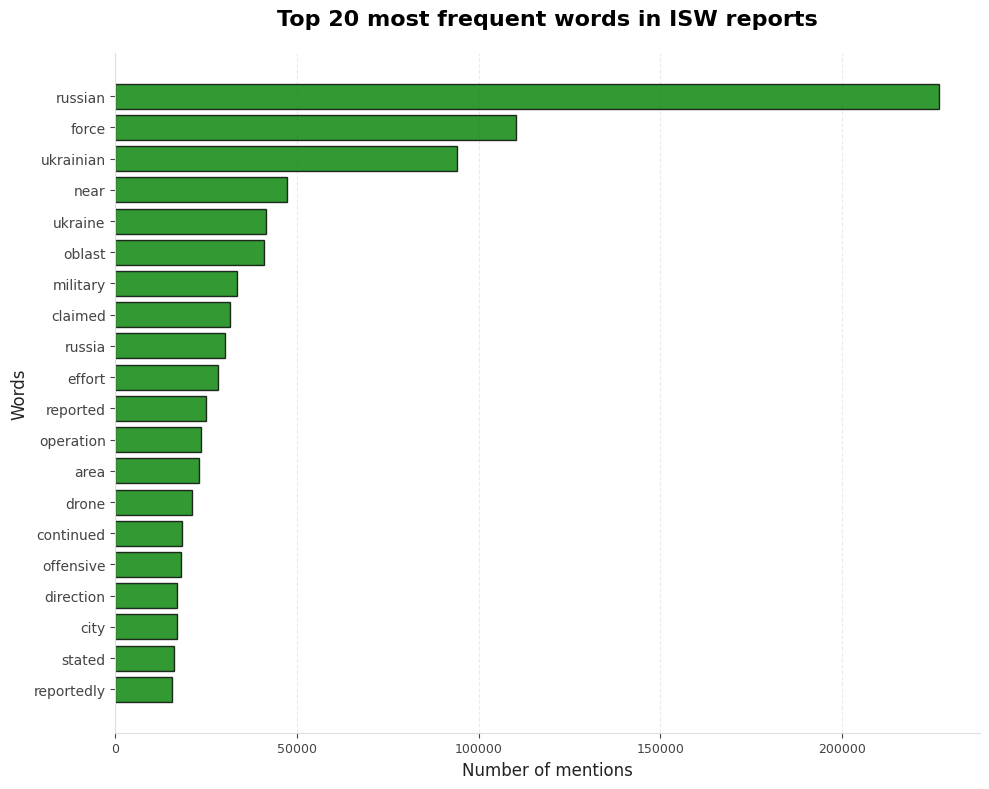

In [128]:
all_words = " ".join(df_isw['text_final']).split()
word_counts = Counter(all_words)

top_20 = word_counts.most_common(20)
words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

plt.figure(figsize=(10, 8))
ax = plt.gca()
ax.set_axisbelow(True)

plt.gca().invert_yaxis()
plt.barh(words, counts, color='green', edgecolor='black', alpha=0.8)
plt.title('Top 20 most frequent words in ISW reports', fontsize=16, pad=20)
plt.xlabel('Number of mentions', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.grid(axis="x", linestyle="--")
plt.tight_layout()

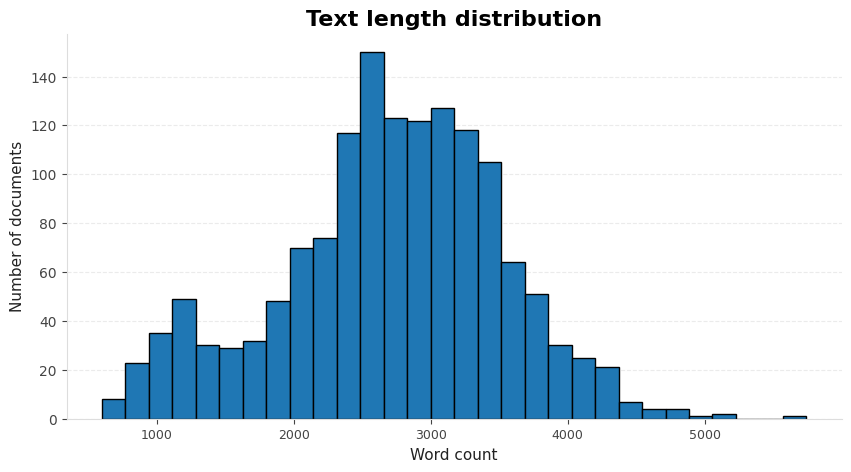

In [129]:
df_isw['doc_length'] = df_isw['text_final'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_axisbelow(True)

plt.hist(df_isw['doc_length'], bins=30, edgecolor='black')
plt.title("Text length distribution")
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.grid(axis="y", linestyle="--")
plt.show()

In [130]:
from sklearn.decomposition import TruncatedSVD

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5)
X_sparse = vectorizer.fit_transform(df_isw['text_final'])

In [131]:
sparsity_tg = (1 - X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1])) * 100
print(f"Sparsity of the ISW matrix: {sparsity_tg:.4f}%")

Sparsity of the ISW matrix: 73.5939%


In [132]:
svd = TruncatedSVD(n_components=200, random_state=42)
X_reduced = svd.fit_transform(X_sparse)

explained_var = svd.explained_variance_ratio_.sum()
print(f"ISW SVD: {X_reduced.shape[1]} components explain {explained_var:.2%} of the information")

df_isw_features = pd.DataFrame(
    X_reduced, 
    columns=[f'isw_topic_{i}' for i in range(200)]
)

df_isw_final = pd.concat([df_isw[['date']].reset_index(drop=True), df_isw_features], axis=1)

ISW SVD: 200 components explain 74.62% of the information


In [133]:
vocab = vectorizer.get_feature_names_out()

rows = []

for i, comp in enumerate(svd.components_):
    top_indices = comp.argsort()[-10:][::-1]
    top_words = [vocab[idx] for idx in top_indices]
    
    rows.append([f"isw_topic_{i}"] + top_words)

df_dict = pd.DataFrame(
    rows,
    columns=["topic/words"] + [f"{j}" for j in range(1, 11)]
)

df_dict.head()

,topic/words,1,2,3,4,5,6,7,8,9,10
0,isw_topic_0,russian,force,ukrainian,russian force,near,oblast,ukraine,military,claimed,effort
1,isw_topic_1,near,drone,pokrovsk,direction,motorized,order battle,motorized rifle,rifle,caa,advanced
2,isw_topic_2,force,izyum,russian force,mariupol,ukrainian,severodonetsk,city,toward,slovyansk,kharkiv
3,isw_topic_3,march,april,ukraine,russia,march russian,april russian,effort,february,mariupol,kyiv
4,isw_topic_4,january,december,march,january russian,february,november,reported january,december russian,january ukrainian,hulyaipole


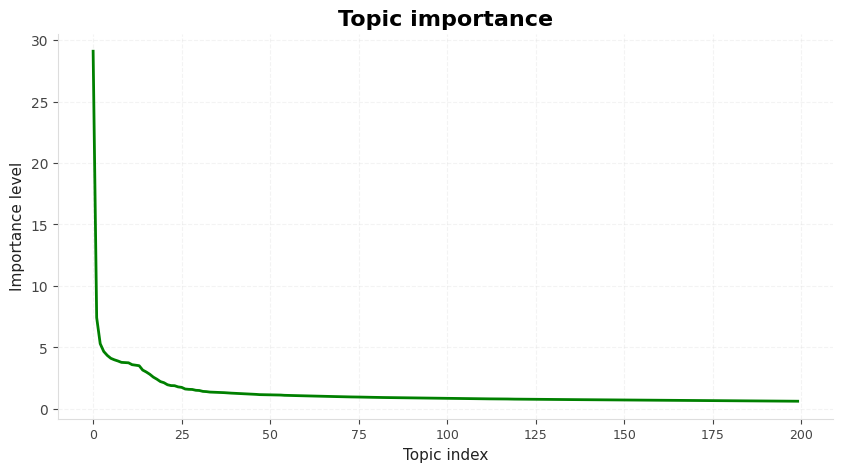

In [134]:
plt.figure(figsize=(10, 5))
plt.plot(svd.singular_values_, color='green', lw=2)
plt.title('Topic importance')
plt.xlabel('Topic index')
plt.ylabel('Importance level')
plt.grid(True, alpha=0.3)
plt.show()

The number of components can be reduced

In [135]:
svd = TruncatedSVD(n_components=150, random_state=42)
X_reduced = svd.fit_transform(X_sparse)

explained_var = svd.explained_variance_ratio_.sum()
print(f"ISW SVD: {X_reduced.shape[1]} components explain {explained_var:.2%} of the information")
df_isw_features = pd.DataFrame(
    X_reduced, 
    columns=[f'isw_topic_{i}' for i in range(150)]
)

df_isw_final = pd.concat([df_isw[['date']].reset_index(drop=True), df_isw_features], axis=1)
df_isw_final.to_csv("isw_processed_svd.csv", index=False, encoding="utf-8-sig")

ISW SVD: 150 components explain 70.88% of the information


## Telegram

In [136]:
tqdm.pandas()
from stop_words import get_stop_words
morph = pymorphy3.MorphAnalyzer(lang='uk')
ua_stop_words = set(get_stop_words('ukrainian'))
trash_words=['telegram', 'whatsapp','viber']
word_cache = {}

def fast_tg_clean_optimized(text):
    text = re.sub(r'https?://\S+|@\w+', '', str(text).lower())
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()

    res = []
    for w in words:
        if len(w) < 3: continue

        if w not in word_cache:
            word_cache[w] = morph.parse(w)[0].normal_form
            
        lemma = word_cache[w]

        if lemma not in ua_stop_words and lemma not in trash_words:
            res.append(lemma)

    return " ".join(res)

print("Cleaning the TG (it will take a couple of minutes)...")
df_tg['message_clean'] = df_tg['message'].progress_apply(fast_tg_clean_optimized)

Cleaning the TG (it will take a couple of minutes)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 130418/130418 [00:31<00:00, 4096.46it/s]


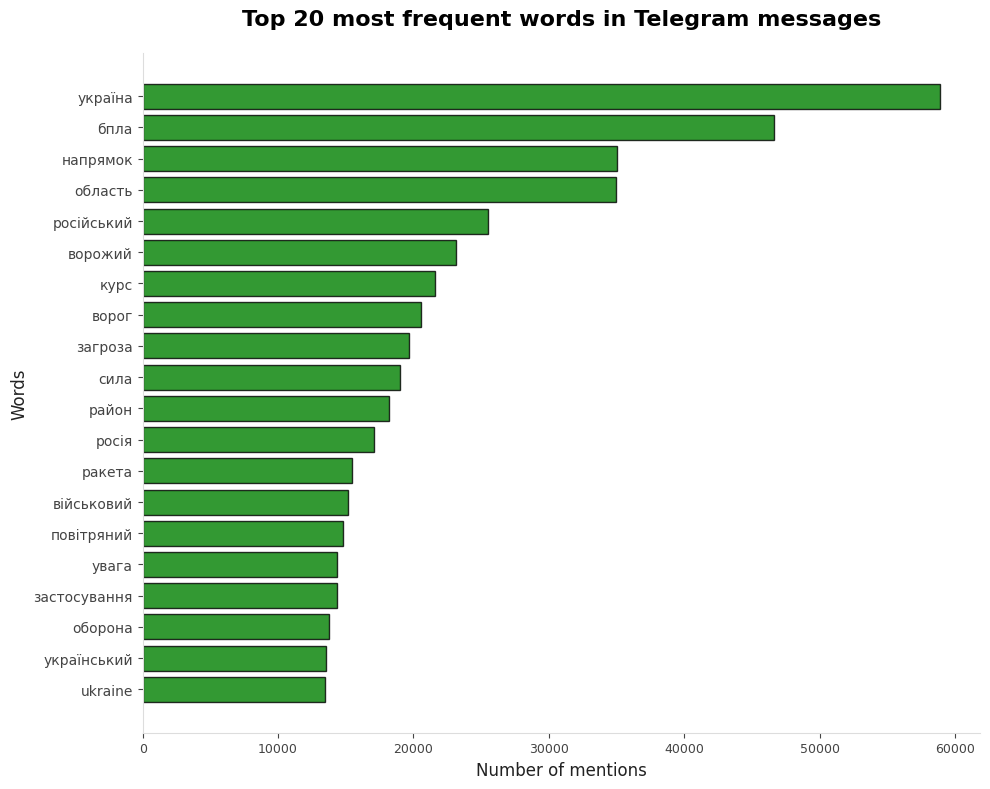

In [137]:
all_words = " ".join(df_tg['message_clean']).split()
word_counts = Counter(all_words)

top_20 = word_counts.most_common(20)
words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

plt.figure(figsize=(10, 8))
plt.gca().invert_yaxis()
plt.barh(words, counts, color='green', edgecolor='black', alpha=0.8)
plt.title('Top 20 most frequent words in Telegram messages', fontsize=16, pad=20)
plt.xlabel('Number of mentions', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()

In [138]:
vectorizer_tg = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    ngram_range=(1, 2),
    dtype=np.float32
)
X_tg_sparse = vectorizer_tg.fit_transform(df_tg['message_clean'])

In [139]:
sparsity_tg = 1.0 - X_tg_sparse.nnz / (X_tg_sparse.shape[0] * X_tg_sparse.shape[1])
print(f"Sparsity of matrix Telegram: {sparsity_tg:.4f}%")

Sparsity of matrix Telegram: 0.9968%


In [140]:
svd_tg = TruncatedSVD(n_components=300, random_state=42) 
X_tg_reduced = svd_tg.fit_transform(X_tg_sparse)

explained_var_tg = svd_tg.explained_variance_ratio_.sum()
print(f"Telegram SVD: {X_tg_reduced.shape[1]} components explain {explained_var_tg:.2%} of the information")

df_tg_features = pd.DataFrame(
    X_tg_reduced, 
    columns=[f'tg_topic_{i}' for i in range(300)]
)

df_tg_final = pd.concat([
    df_tg[['date', 'channel']].reset_index(drop=True), 
    df_tg_features.reset_index(drop=True)
], axis=1)

Telegram SVD: 300 components explain 48.04% of the information


In [141]:
vocab = vectorizer_tg.get_feature_names_out()

rows = []

for i, comp in enumerate(svd_tg.components_):
    top_indices = comp.argsort()[-10:][::-1]
    top_words = [vocab[idx] for idx in top_indices]
    
    rows.append([f"tg_topic_{i}"] + top_words)

df_dict = pd.DataFrame(
    rows,
    columns=["topic/words"] + [f"{j}" for j in range(1, 11)]
)

df_dict.head()

,topic/words,1,2,3,4,5,6,7,8,9,10
0,tg_topic_0,загроза,загроза застосування,застосування,відбій,відбій загроза,тактичний авіація,тактичний,ворожий тактичний,авіація,область
1,tg_topic_1,відбій,відбій загроза,загроза,балістичний озброєння,застосування балістичний,балістичний,озброєння,загроза застосування,застосування,ударний бпла
2,tg_topic_2,бпла,курс,ударний,ударний бпла,західний,напрямок,область,група,півночі,чернігівщина
3,tg_topic_3,пуск,відбій,каб,відбій загроза,пуск каб,донеччина,пуск керований,авіаційний бомба,сумщина,бомба
4,tg_topic_4,відбій,відбій загроза,курс,бпла,напрямок,активність ворожий,активність,західний,східний,авіаційний засіб


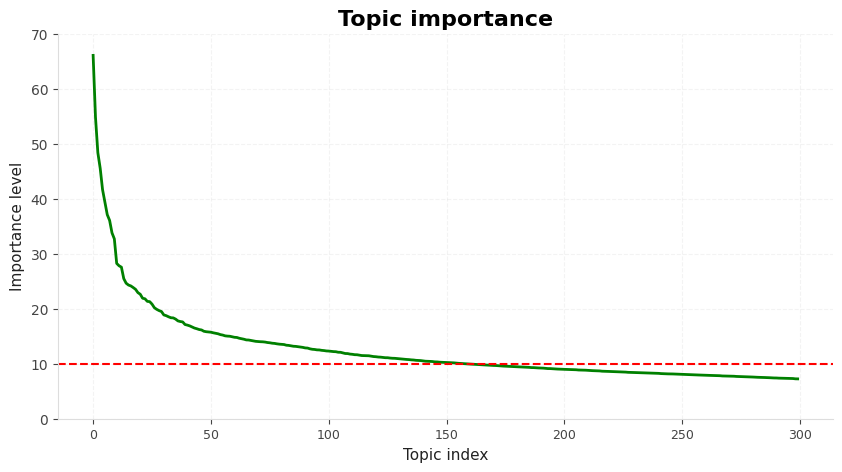

In [142]:
plt.figure(figsize=(10, 5))
plt.plot(svd_tg.singular_values_, color='green', lw=2) 
plt.axhline(y=10, color='red', linestyle='--', label='Importance Threshold (10)')
plt.ylim(0, 70)
plt.title('Topic importance')
plt.xlabel('Topic index')
plt.ylabel('Importance level')
plt.grid(True, alpha=0.3)
plt.show()

In [143]:
svd_tg = TruncatedSVD(n_components=250, random_state=42) 
X_tg_reduced = svd_tg.fit_transform(X_tg_sparse)

explained_var_tg = svd_tg.explained_variance_ratio_.sum()
print(f"Telegram SVD: {X_tg_reduced.shape[1]} components explain {explained_var_tg:.2%} of the information")

df_tg_features = pd.DataFrame(
    X_tg_reduced, 
    columns=[f'tg_topic_{i}' for i in range(250)]
)

df_tg_final = pd.concat([
    df_tg[['date', 'channel']].reset_index(drop=True), 
    df_tg_features.reset_index(drop=True)
], axis=1)

df_tg_final.to_csv("telegram_processed_svd.csv", index=False, encoding="utf-8-sig")

Telegram SVD: 250 components explain 45.64% of the information


## War events (alarms)

In [144]:
df_war_events.head()

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms,duration_min,region_key
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,13.0,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]",129.183333,Львівська
1,71822,a6fa45504565dc0928efc8807db66487,25.0,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]",191.000000,Чернігівська
2,1746,c0ff722f9fac93e89919c7b09695dda5,2.0,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]",30.000000,Вінницька
3,55540,066e25a0712b306a9b95230f6ec4a051,20.0,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]",48.000000,Харківська
4,54611,73dcb24720672b203e7c6763639860f3,19.0,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]",420.716667,Тернопільська


In [145]:
df_war_events = df_war_events[df_war_events["region_id"] != 5]

In [146]:
rows = []

for row in df_war_events[["id", "region_id", "region_key", "start", "end"]].itertuples(index=False):
    start_hour = row.start.floor("h")
    end_hour = row.end.floor("h")

    for hour in pd.date_range(start_hour, end_hour, freq="h"):
        hour_end = hour + pd.Timedelta(hours=1)

        overlap_start = max(row.start, hour)
        overlap_end = min(row.end, hour_end)

        overlap_min = (overlap_end - overlap_start).total_seconds() / 60

        if overlap_min > 0:
            rows.append({
                "datetime_hour": hour,
                "region_id": row.region_id,
                "region_key": row.region_key,
                "alarm_minutes_in_hour": overlap_min,
                "alarm_active": 1,
                "alarm_id": row.id
            })

df_alarm_hourly = pd.DataFrame(rows)

df_alarm_hourly = (
    df_alarm_hourly
    .groupby(["datetime_hour", "region_id", "region_key"], as_index=False)
    .agg(
        alarm_minutes_in_hour=("alarm_minutes_in_hour", "sum"),
        alarm_active=("alarm_active", "max"),
    )
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly["alarm_minutes_in_hour"] = df_alarm_hourly["alarm_minutes_in_hour"].clip(0, 60)

print(df_alarm_hourly[["region_id", "region_key"]].drop_duplicates())

      region_id         region_key
0          13.0          Львівська
3          25.0       Чернігівська
4           2.0          Вінницька
9          20.0         Харківська
10         19.0      Тернопільська
26         26.0               Київ
30         17.0         Рівненська
44         23.0          Черкаська
45         15.0            Одеська
48          8.0         Запорізька
52          3.0          Волинська
79          6.0        Житомирська
88         21.0         Херсонська
100        14.0       Миколаївська
115        22.0        Хмельницька
129         9.0  Івано-Франківська
171         4.0   Дніпропетровська
218        11.0     Кіровоградська
238        24.0        Чернівецька
276        16.0         Полтавська
450        10.0           Київська
595        18.0            Сумська
1375        7.0       Закарпатська


In [147]:
start_dt = pd.Timestamp("2022-02-24 00:00:00")

end_dt = min(
    df_weather["datetime_hour"].max(),
    df_alarm_hourly["datetime_hour"].max()
)

all_hours = pd.date_range(start_dt, end_dt, freq="h")

regions_dim = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region": "region_key"})
)

kyiv_row = pd.DataFrame([{
    "region_id": 26,
    "region_key": "Київ"
}])

regions_dim = (
    pd.concat([regions_dim, kyiv_row], ignore_index=True)
    .drop_duplicates(subset=["region_id", "region_key"])
    .sort_values("region_id")
    .reset_index(drop=True)
)

backbone = (
    pd.MultiIndex.from_product(
        [all_hours, regions_dim["region_id"]],
        names=["datetime_hour", "region_id"]
    )
    .to_frame(index=False)
    .merge(regions_dim, on="region_id", how="left")
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly_full = backbone.merge(
    df_alarm_hourly,
    on=["datetime_hour", "region_id", "region_key"],
    how="left"
)

for col in ["alarm_minutes_in_hour", "alarm_active"]:
    df_alarm_hourly_full[col] = df_alarm_hourly_full[col].fillna(0)

df_alarm_hourly_full["alarm_active"] = df_alarm_hourly_full["alarm_active"].astype(int)

print(df_alarm_hourly_full[["region_id", "region_key"]].drop_duplicates())

    region_id         region_key
0           1            АР Крим
1           2          Вінницька
2           3          Волинська
3           4   Дніпропетровська
4           5           Донецька
5           6        Житомирська
6           7       Закарпатська
7           8         Запорізька
8           9  Івано-Франківська
9          10           Київська
10         11     Кіровоградська
11         12          Луганська
12         13          Львівська
13         14       Миколаївська
14         15            Одеська
15         16         Полтавська
16         17         Рівненська
17         18            Сумська
18         19      Тернопільська
19         20         Харківська
20         21         Херсонська
21         22        Хмельницька
22         23          Черкаська
23         24        Чернівецька
24         25       Чернігівська
25         26               Київ


In [148]:
def last_sunday_of_march(year):
    cal = monthcalendar(year, 3)
    day = max(week[SUNDAY] for week in cal)
    return pd.Timestamp(year=year, month=3, day=day, hour=3)

years = sorted(df_alarm_hourly_full["datetime_hour"].dt.year.unique())

spring_missing_hours = pd.to_datetime([last_sunday_of_march(y) for y in years])

print("Spring hours to remove:")
print(spring_missing_hours)

mask_spring = df_alarm_hourly_full["datetime_hour"].isin(spring_missing_hours)

print("Rows to remove from war_events:", mask_spring.sum())
print(df_alarm_hourly_full.loc[mask_spring, ["datetime_hour", "region_id", "region_key"]].head(10))

df_alarm_hourly_full = (
    df_alarm_hourly_full.loc[~mask_spring]
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

print("War events shape after removing spring hour:", df_alarm_hourly_full.shape)

Spring hours to remove:
DatetimeIndex(['2022-03-27 03:00:00', '2023-03-26 03:00:00',
               '2024-03-31 03:00:00', '2025-03-30 03:00:00',
               '2026-03-29 03:00:00'],
              dtype='datetime64[ns]', freq=None)
Rows to remove from war_events: 104
            datetime_hour  region_id         region_key
19422 2022-03-27 03:00:00          1            АР Крим
19423 2022-03-27 03:00:00          2          Вінницька
19424 2022-03-27 03:00:00          3          Волинська
19425 2022-03-27 03:00:00          4   Дніпропетровська
19426 2022-03-27 03:00:00          5           Донецька
19427 2022-03-27 03:00:00          6        Житомирська
19428 2022-03-27 03:00:00          7       Закарпатська
19429 2022-03-27 03:00:00          8         Запорізька
19430 2022-03-27 03:00:00          9  Івано-Франківська
19431 2022-03-27 03:00:00         10           Київська
War events shape after removing spring hour: (924664, 5)


## Weather 

In [149]:
city_to_region = {
    "Vinnytsia": "Вінницька",
    "Lutsk": "Волинська",
    "Dnipro": "Дніпропетровська",
    "Donetsk": "Донецька",
    "Zhytomyr": "Житомирська",
    "Uzhgorod": "Закарпатська",
    "Zaporozhye": "Запорізька",
    "Ivano-Frankivsk": "Івано-Франківська",
    "Kyiv": "Київ",
    "Kropyvnytskyi": "Кіровоградська",
    "Luhansk": "Луганська",
    "Lviv": "Львівська",
    "Mykolaiv": "Миколаївська",
    "Odesa": "Одеська",
    "Poltava": "Полтавська",
    "Rivne": "Рівненська",
    "Sumy": "Сумська",
    "Ternopil": "Тернопільська",
    "Kharkiv": "Харківська",
    "Kherson": "Херсонська",
    "Khmelnytskyi": "Хмельницька",
    "Cherkasy": "Черкаська",
    "Chernivtsi": "Чернівецька",
    "Chernihiv": "Чернігівська",
}

df_weather["region_key"] = df_weather["city_name"].map(city_to_region)

region_id_map = df_regions.set_index("region")["region_id"].to_dict()
region_id_map["Київ"] = 26

df_weather["region_id"] = df_weather["region_key"].map(region_id_map)

kyiv_weather = df_weather[df_weather["region_id"] == 26].copy()
kyivska_weather = kyiv_weather.copy()

kyivska_weather["region_id"] = 10
kyivska_weather["region_key"] = "Київська"

df_weather = (
    pd.concat([df_weather, kyivska_weather], ignore_index=True)
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

print(df_weather[["city_name", "region_key", "region_id"]].drop_duplicates())
print("Missing region_id:", df_weather["region_id"].isna().sum())

          city_name         region_key  region_id
0         Vinnytsia          Вінницька          2
1             Lutsk          Волинська          3
2            Dnipro   Дніпропетровська          4
3           Donetsk           Донецька          5
4          Zhytomyr        Житомирська          6
5          Uzhgorod       Закарпатська          7
6        Zaporozhye         Запорізька          8
7   Ivano-Frankivsk  Івано-Франківська          9
8              Kyiv           Київська         10
9     Kropyvnytskyi     Кіровоградська         11
10             Lviv          Львівська         13
11         Mykolaiv       Миколаївська         14
12            Odesa            Одеська         15
13          Poltava         Полтавська         16
14            Rivne         Рівненська         17
15             Sumy            Сумська         18
16         Ternopil      Тернопільська         19
17          Kharkiv         Харківська         20
18          Kherson         Херсонська         21


In [150]:
columns_to_delete = ['city_latitude', 'city_longitude', 'day_snowdepth', 'day_windspeed', 'day_winddir', 'day_pressure', 'day_solarradiation',
                     'day_solarenergy', 'day_uvindex', 'day_conditions_simple_Clear', 'day_conditions_simple_Cloudy', 'day_conditions_simple_Rain',
                     'day_conditions_simple_Snow', 'year', 'month', 'city_timezone', 'hour_datetime', 'hour_precipprob', 'day_precipprob']
df_weather = df_weather.drop(columns=columns_to_delete)
df_weather.shape

(844417, 39)

In [151]:
df_weather_trimmed = df_weather[(df_weather["datetime_hour"] >= start_dt) & (df_weather["datetime_hour"] <= end_dt)]

In [152]:
df_alarm_hourly_full.head()

,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active
0,2022-02-24,1,АР Крим,0.0,0
1,2022-02-24,2,Вінницька,0.0,0
2,2022-02-24,3,Волинська,0.0,0
3,2022-02-24,4,Дніпропетровська,0.0,0
4,2022-02-24,5,Донецька,0.0,0


In [153]:
df_alarm_hourly_full.tail()

,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active
924659,2026-03-16 23:00:00,22,Хмельницька,0.000000,0
924660,2026-03-16 23:00:00,23,Черкаська,0.000000,0
924661,2026-03-16 23:00:00,24,Чернівецька,0.000000,0
924662,2026-03-16 23:00:00,25,Чернігівська,60.000000,1
924663,2026-03-16 23:00:00,26,Київ,17.216667,1


In [154]:
df_weather_trimmed.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,day_windgust,day_cloudcover,day_moonphase,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,day_of_week,hour,day_datetime,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id
0,Vinnytsia,2022-02-24,5.0,0.7,2.8,-0.3,80.5,0.300,4.17,0.0,27.7,82.5,0.77,2.1,-0.5,91.76,0.9,0.0,0.0,0.0,16.6,8.6,279.6,1021.0,91.1,0.0,0.1,0.0,3,0,2022-02-24,06:58:49,17:40:52,False,True,False,False,Вінницька,2
1,Lutsk,2022-02-24,4.9,0.7,2.6,0.0,83.7,0.118,4.17,0.1,32.4,72.3,0.77,2.4,-1.6,89.18,0.8,0.0,0.1,0.2,31.3,15.5,275.6,1020.0,91.5,0.0,0.1,0.0,3,0,2022-02-24,07:13:36,17:51:06,False,True,False,False,Волинська,3
2,Dnipro,2022-02-24,8.0,-2.0,3.1,-2.2,70.6,0.000,0.00,0.0,28.4,53.6,0.77,2.0,-1.1,80.51,-1.0,0.0,0.0,0.0,9.7,10.8,4.0,1019.0,14.1,0.0,0.1,0.0,3,0,2022-02-24,06:31:28,17:15:39,True,False,False,False,Дніпропетровська,4
3,Donetsk,2022-02-24,5.6,1.9,3.6,0.7,81.0,1.300,20.83,0.0,41.4,98.6,0.77,3.7,3.7,74.03,-0.5,0.0,0.0,0.0,8.3,4.7,332.7,1020.0,95.7,0.0,0.1,0.0,3,0,2022-02-24,06:19:37,17:05:06,False,True,False,False,Донецька,5
4,Zhytomyr,2022-02-24,5.5,1.5,3.3,0.2,80.8,0.800,4.17,0.0,25.9,85.9,0.77,2.2,-0.9,90.45,0.8,0.0,0.0,0.0,20.2,10.8,280.4,1020.0,95.6,0.0,0.1,0.0,3,0,2022-02-24,06:59:29,17:38:29,False,True,False,False,Житомирська,6


In [155]:
df_weather_trimmed.tail()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,day_windgust,day_cloudcover,day_moonphase,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,day_of_week,hour,day_datetime,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id
844412,Khmelnytskyi,2026-03-16 23:00:00,11.8,-0.4,5.5,-1.7,61.8,0.0,0.0,0.0,31.7,5.8,0.92,3.1,3.1,71.78,-1.5,0.0,0.0,0.0,6.1,3.6,103.8,1019.0,0.0,5.5,0.1,0.0,0,23,2026-03-16,06:23:50,18:18:39,True,False,False,False,Хмельницька,22
844413,Cherkasy,2026-03-16 23:00:00,10.3,0.7,5.1,-0.5,68.4,0.0,0.0,0.0,19.8,43.9,0.92,4.1,4.1,78.52,0.7,0.0,0.0,0.0,7.9,4.3,43.3,1020.0,78.4,5.5,0.1,0.0,0,23,2026-03-16,06:03:31,17:58:16,False,True,False,False,Черкаська,23
844414,Chernivtsi,2026-03-16 23:00:00,12.0,2.0,6.7,-2.6,52.3,0.0,0.0,0.0,33.8,9.4,0.92,5.0,1.7,60.55,-2.0,0.0,0.0,0.0,5.8,14.8,170.0,1017.0,14.3,5.5,0.1,0.0,0,23,2026-03-16,06:27:47,18:22:59,True,False,False,False,Чернівецька,24
844415,Chernihiv,2026-03-16 23:00:00,11.0,-1.2,4.5,-1.9,66.0,0.0,0.0,0.0,21.2,6.9,0.92,2.1,0.3,83.52,-0.4,0.0,0.0,0.0,13.7,6.1,81.5,1022.0,8.4,5.5,0.1,0.0,0,23,2026-03-16,06:06:59,18:01:02,True,False,False,False,Чернігівська,25
844416,Kyiv,2026-03-16 23:00:00,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,25.6,15.5,0.92,4.7,4.7,66.06,-1.1,0.0,0.0,0.0,5.8,2.2,63.2,1021.0,10.6,5.5,0.1,0.0,0,23,2026-03-16,06:09:51,18:04:17,True,False,False,False,Київ,26


In [156]:
df_weather_trimmed.isna().sum()

city_name                        0
datetime_hour                    0
day_tempmax                      0
day_tempmin                      0
day_temp                         0
day_dew                          0
day_humidity                     0
day_precip                       0
day_precipcover                  0
day_snow                         0
day_windgust                     0
day_cloudcover                   0
day_moonphase                    0
hour_temp                        0
hour_feelslike                   0
hour_humidity                    0
hour_dew                         0
hour_precip                      0
hour_snow                        0
hour_snowdepth                   0
hour_windgust                    0
hour_windspeed                   0
hour_winddir                     0
hour_pressure                    0
hour_cloudcover                  0
hour_solarradiation              0
hour_solarenergy                 0
hour_uvindex                     0
day_of_week         

In [157]:
df_alarm_hourly_full.to_csv("war_events_processed.csv", index=False, encoding="utf-8-sig")
df_weather_trimmed.to_csv("weather_processed.csv", index=False, encoding="utf-8-sig")